In [17]:
import sys
!{sys.executable} -m pip install --upgrade pandas pyarrow

  ✓ P_DR1TOT.XPT        (Day-1 total nutrient intakes) — downloaded, 18792 KB
  ✓ P_DR1IFF.XPT        (Day-1 individual foods) — downloaded, 120703 KB
  ✓ P_DRXFCD.XPT        (Food code dictionary) — downloaded, 4857 KB
  ✓ P_HSCRP.XPT         (High-sensitivity CRP) — downloaded, 323 KB
  ✓ P_DEMO.XPT          (Demographics) — downloaded, 3530 KB
  ✓ P_BMX.XPT           (Body measurements) — downloaded, 2461 KB
DR1TOT (dietary):      14,300 rows × 168 cols
HSCRP  (CRP):          13,772 rows ×   3 cols
DEMO   (demographics): 15,560 rows ×  29 cols
BMX    (body meas.):   14,300 rows ×  22 cols
DII feature matrix: 14,300 participants × 27 components

DII computed for 14,300 participants
count    14300.000000
mean         0.931662
std          1.698407
min         -4.946304
25%          0.013069
50%          0.877437
75%          2.256377
max          4.932256
Name: dii_score, dtype: float64

Sanity vs. published NHANES DII (mean ~0.4, range ~-5 to +5):
  Our mean: 0.93
  Our range: [-4.95

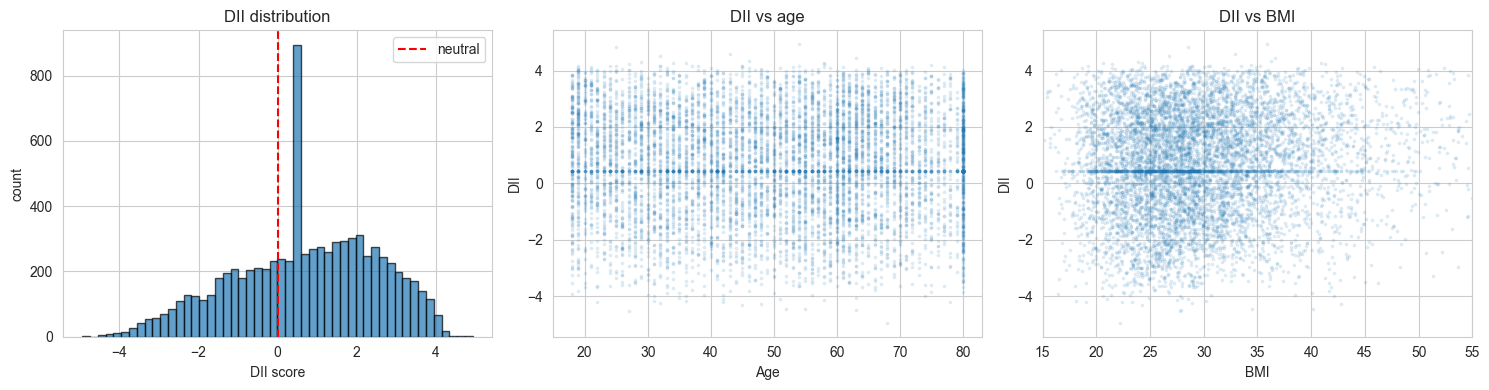

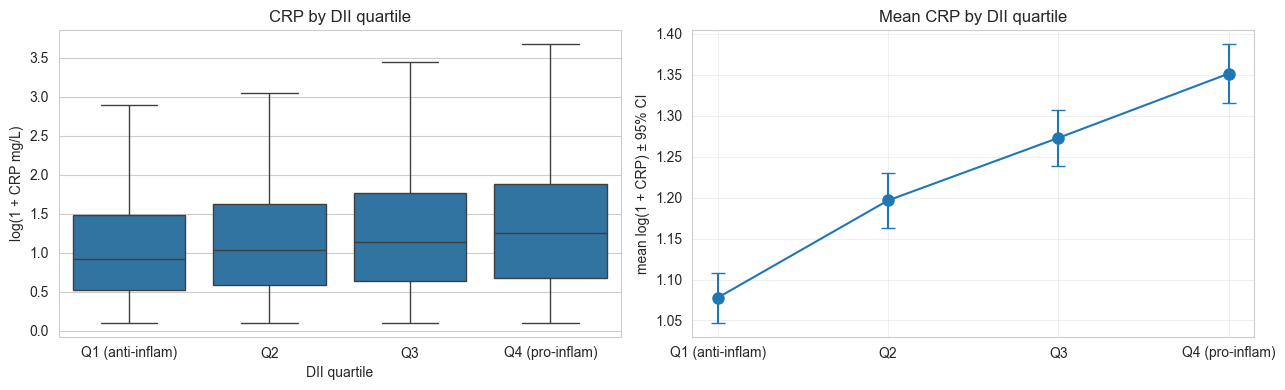


Per-quartile mean CRP (mg/L):
                  mean  median  count
dii_quartile                         
Q1 (anti-inflam)  3.08    1.53   2026
Q2                4.12    1.82   2025
Q3                4.30    2.11   2025
Q4 (pro-inflam)   5.01    2.50   2026

Spearman(DII, CRP):       ρ = +0.132  (p = 4.99e-33)
Pearson(DII, log(1+CRP)): r = +0.137  (p = 3.43e-35)
Published NHANES benchmark: ρ typically in [0.05, 0.15]. In range = correct implementation.

Training quantile regressors...
  q=0.10: empirical coverage = 0.104 (target 0.100)
  q=0.25: empirical coverage = 0.262 (target 0.250)
  q=0.50: empirical coverage = 0.486 (target 0.500)
  q=0.75: empirical coverage = 0.752 (target 0.750)
  q=0.90: empirical coverage = 0.897 (target 0.900)
  q=0.95: empirical coverage = 0.941 (target 0.950)
  q=0.99: empirical coverage = 0.983 (target 0.990)

Smoke test:
  age=30 sex=M bmi=22  DII=-1.0  →  percentile 29%
  age=30 sex=M bmi=22  DII=+2.0  →  percentile 81%
  age=60 sex=F bmi=30  DII=+0.

In [1]:
# =============================================================================
# ImmunoSense — Agent 2 (Dietary) — Layer 1 Exploration
# Mirror of Agent 1's Layer 1: population baseline via quantile regression.
# Data: NHANES 2017-March 2020. Validates DII↔CRP at population level.
# =============================================================================

# ---- 1. Setup ----
import os
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from sklearn.model_selection import train_test_split
from scipy.stats import norm, spearmanr, pearsonr
import joblib

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('./data/nhanes')
DATA_DIR.mkdir(parents=True, exist_ok=True)


# ---- 2. Download NHANES files ----
NHANES_BASE = 'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles'

FILES = {
    'P_DR1TOT.XPT': 'Day-1 total nutrient intakes',
    'P_DR1IFF.XPT': 'Day-1 individual foods',
    'P_DRXFCD.XPT': 'Food code dictionary',
    'P_HSCRP.XPT' : 'High-sensitivity CRP',
    'P_DEMO.XPT'  : 'Demographics',
    'P_BMX.XPT'   : 'Body measurements',
}

def download_nhanes(filename: str, description: str) -> Path:
    target = DATA_DIR / filename
    if target.exists() and target.stat().st_size > 0:
        print(f'  ✓ {filename:18s}  ({description}) — cached')
        return target
    url = f'{NHANES_BASE}/{filename}'
    try:
        urllib.request.urlretrieve(url, target)
        size_kb = target.stat().st_size // 1024
        print(f'  ✓ {filename:18s}  ({description}) — downloaded, {size_kb} KB')
    except Exception as e:
        print(f'  ✗ {filename:18s}  FAILED: {e}')
        if target.exists():
            target.unlink()
    return target

print('Downloading NHANES 2017-March 2020 data files...')
paths = {f: download_nhanes(f, d) for f, d in FILES.items()}


# ---- 3. Load and prep ----
def load_xpt(path: Path) -> pd.DataFrame:
    if not path.exists() or path.stat().st_size == 0:
        raise FileNotFoundError(f'{path} not available — re-run the download cell')
    return pd.read_sas(path, format='xport')

df_dr1tot = load_xpt(paths['P_DR1TOT.XPT'])
df_crp    = load_xpt(paths['P_HSCRP.XPT'])
df_demo   = load_xpt(paths['P_DEMO.XPT'])
df_bmx    = load_xpt(paths['P_BMX.XPT'])

print(f'DR1TOT (dietary):      {len(df_dr1tot):>6,} rows × {df_dr1tot.shape[1]:>3} cols')
print(f'HSCRP  (CRP):          {len(df_crp):>6,} rows × {df_crp.shape[1]:>3} cols')
print(f'DEMO   (demographics): {len(df_demo):>6,} rows × {df_demo.shape[1]:>3} cols')
print(f'BMX    (body meas.):   {len(df_bmx):>6,} rows × {df_bmx.shape[1]:>3} cols')

# Select and rename the columns we use.
# RIAGENDR: 1=M, 2=F. RIDAGEYR: age years. RIDRETH3: race/ethnicity. BMXBMI: BMI. LBXHSCRP: mg/L.
df_demo = df_demo[['SEQN', 'RIAGENDR', 'RIDAGEYR', 'RIDRETH3']].rename(
    columns={'RIAGENDR': 'sex', 'RIDAGEYR': 'age', 'RIDRETH3': 'race_eth'})
df_bmx  = df_bmx[['SEQN', 'BMXBMI']].rename(columns={'BMXBMI': 'bmi'})
df_crp  = df_crp[['SEQN', 'LBXHSCRP']].rename(columns={'LBXHSCRP': 'crp_mg_l'})


# ---- 4. DII reference (Shivappa et al. 2014, 28 NHANES-available components) ----
# Format: component → (global_mean, global_sd, inflammatory_effect_score)
# Negative effect = anti-inflammatory. Positive = pro-inflammatory.
DII_REF = {
    'energy_kcal':          (2056.0,    338.0,   0.180),
    'carbohydrate_g':       ( 272.2,     40.0,   0.097),
    'protein_g':            (  79.4,     13.9,   0.021),
    'fat_total_g':          (  71.4,     19.4,   0.298),
    'saturated_fat_g':      (  28.6,      8.0,   0.373),
    'mufa_g':               (  27.0,      6.1,  -0.009),
    'pufa_g':               (  13.9,      3.9,  -0.337),
    'omega3_g':             (   1.06,     1.06, -0.436),
    'omega6_g':             (  10.8,      7.5,  -0.159),
    'cholesterol_mg':       ( 279.4,     51.2,   0.110),
    'fiber_g':              (  18.8,      4.9,  -0.663),
    'vit_a_mcg_rae':        ( 983.9,    518.6, -0.401),
    'vit_b1_thiamin_mg':    (   1.70,     0.66, -0.098),
    'vit_b2_riboflavin_mg': (   1.70,     0.79, -0.068),
    'vit_b3_niacin_mg':     (  25.90,    11.77, -0.246),
    'vit_b6_mg':            (   1.47,     0.74, -0.365),
    'vit_b12_mcg':          (   5.15,     2.70,  0.106),
    'folate_mcg':           ( 273.0,     70.7, -0.190),
    'vit_c_mg':             ( 118.2,     43.46, -0.424),
    'vit_d_mcg':            (   6.26,     2.21, -0.446),
    'vit_e_mg':             (   8.73,     1.49, -0.419),
    'iron_mg':              (  13.35,     3.71,  0.032),
    'magnesium_mg':         ( 310.1,    139.4, -0.484),
    'selenium_mcg':         (  67.0,     25.1, -0.191),
    'zinc_mg':              (   9.84,     2.19, -0.313),
    'caffeine_g':           (   8.05,     6.67, -0.110),
    'alcohol_g':            (  13.98,     3.72, -0.278),
}

# NHANES DR1TOT column names per component.
# Reference: https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_DR1TOT.htm
NHANES_COL_MAP = {
    'energy_kcal':          'DR1TKCAL',
    'carbohydrate_g':       'DR1TCARB',
    'protein_g':            'DR1TPROT',
    'fat_total_g':          'DR1TTFAT',
    'saturated_fat_g':      'DR1TSFAT',
    'mufa_g':               'DR1TMFAT',
    'pufa_g':               'DR1TPFAT',
    'omega3_g':             None,   # derived from fatty acids
    'omega6_g':             None,   # derived from fatty acids
    'cholesterol_mg':       'DR1TCHOL',
    'fiber_g':              'DR1TFIBE',
    'vit_a_mcg_rae':        'DR1TVARA',
    'vit_b1_thiamin_mg':    'DR1TVB1',
    'vit_b2_riboflavin_mg': 'DR1TVB2',
    'vit_b3_niacin_mg':     'DR1TNIAC',
    'vit_b6_mg':            'DR1TVB6',
    'vit_b12_mcg':          'DR1TVB12',
    'folate_mcg':           'DR1TFOLA',
    'vit_c_mg':             'DR1TVC',
    'vit_d_mcg':            'DR1TVD',
    'vit_e_mg':             'DR1TATOC',
    'iron_mg':              'DR1TIRON',
    'magnesium_mg':         'DR1TMAGN',
    'selenium_mcg':         'DR1TSELE',
    'zinc_mg':              'DR1TZINC',
    'caffeine_g':           'DR1TCAFF',   # NHANES reports mg → convert
    'alcohol_g':            'DR1TALCO',
}

dii_features = pd.DataFrame({'SEQN': df_dr1tot['SEQN']})
for component, nhanes_col in NHANES_COL_MAP.items():
    if nhanes_col is None:
        continue
    if nhanes_col in df_dr1tot.columns:
        dii_features[component] = df_dr1tot[nhanes_col]
    else:
        print(f'  ! Missing NHANES column for {component}: {nhanes_col}')
        dii_features[component] = np.nan

# Caffeine: mg → g
dii_features['caffeine_g'] = dii_features['caffeine_g'] / 1000.0

# Omega-3 / Omega-6 from individual fatty acid columns
omega3_cols = [c for c in ['DR1TP183', 'DR1TP205', 'DR1TP225', 'DR1TP226'] if c in df_dr1tot.columns]
omega6_cols = [c for c in ['DR1TP182', 'DR1TP204'] if c in df_dr1tot.columns]
if omega3_cols:
    dii_features['omega3_g'] = df_dr1tot[omega3_cols].sum(axis=1)
if omega6_cols:
    dii_features['omega6_g'] = df_dr1tot[omega6_cols].sum(axis=1)

print(f'DII feature matrix: {dii_features.shape[0]:,} participants × {dii_features.shape[1]-1} components')


# ---- 5. Compute DII per participant (Shivappa scoring) ----
def compute_dii_row(intake_row: pd.Series, ref: dict) -> float:
    """For each component:
       z = (intake - global_mean) / global_sd
       percentile = Phi(z); centered = 2*percentile - 1; score = centered * effect.
       Sum across components. NaN components skipped.
    """
    total = 0.0
    n_used = 0
    for component, (mu, sd, effect) in ref.items():
        v = intake_row.get(component, np.nan)
        if pd.isna(v):
            continue
        z = (v - mu) / sd
        centered = (norm.cdf(z) * 2.0) - 1.0
        total += centered * effect
        n_used += 1
    return total if n_used > 0 else np.nan

dii_scores = dii_features.apply(lambda r: compute_dii_row(r, DII_REF), axis=1)
df_dii = pd.DataFrame({'SEQN': dii_features['SEQN'], 'dii_score': dii_scores})

print(f'\nDII computed for {df_dii["dii_score"].notna().sum():,} participants')
print(df_dii['dii_score'].describe())
print('\nSanity vs. published NHANES DII (mean ~0.4, range ~-5 to +5):')
print(f'  Our mean: {df_dii["dii_score"].mean():.2f}')
print(f'  Our range: [{df_dii["dii_score"].min():.2f}, {df_dii["dii_score"].max():.2f}]')


# ---- 6. Merge to master adult dataframe ----
df = (df_dii
      .merge(df_demo, on='SEQN', how='inner')
      .merge(df_bmx,  on='SEQN', how='inner')
      .merge(df_crp,  on='SEQN', how='inner'))

df = df.dropna(subset=['dii_score', 'age', 'sex', 'bmi', 'crp_mg_l'])
df = df[df['age'] >= 18].copy()

print(f'\nMerged + filtered to complete adult cases: {len(df):,}')
print(df.head())
print('\nSex distribution:')
print(df['sex'].value_counts())


# ---- 7. EDA ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['dii_score'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', label='neutral')
axes[0].set_xlabel('DII score'); axes[0].set_ylabel('count'); axes[0].set_title('DII distribution')
axes[0].legend()

axes[1].scatter(df['age'], df['dii_score'], alpha=0.1, s=3)
axes[1].set_xlabel('Age'); axes[1].set_ylabel('DII'); axes[1].set_title('DII vs age')

axes[2].scatter(df['bmi'], df['dii_score'], alpha=0.1, s=3)
axes[2].set_xlabel('BMI'); axes[2].set_ylabel('DII'); axes[2].set_title('DII vs BMI')
axes[2].set_xlim(15, 55)

plt.tight_layout(); plt.show()


# ---- 8. Validation: DII vs CRP ----
df['log_crp'] = np.log1p(df['crp_mg_l'])
df['dii_quartile'] = pd.qcut(df['dii_score'], q=4,
                              labels=['Q1 (anti-inflam)', 'Q2', 'Q3', 'Q4 (pro-inflam)'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(data=df, x='dii_quartile', y='log_crp', ax=axes[0], showfliers=False)
axes[0].set_xlabel('DII quartile'); axes[0].set_ylabel('log(1 + CRP mg/L)')
axes[0].set_title('CRP by DII quartile')

summary = df.groupby('dii_quartile')['log_crp'].agg(['mean', 'std', 'count']).reset_index()
summary['ci95'] = 1.96 * summary['std'] / np.sqrt(summary['count'])
axes[1].errorbar(range(len(summary)), summary['mean'], yerr=summary['ci95'],
                 fmt='o-', capsize=5, markersize=8)
axes[1].set_xticks(range(len(summary)))
axes[1].set_xticklabels(summary['dii_quartile'])
axes[1].set_ylabel('mean log(1 + CRP) ± 95% CI')
axes[1].set_title('Mean CRP by DII quartile')
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('\nPer-quartile mean CRP (mg/L):')
print(df.groupby('dii_quartile')['crp_mg_l'].agg(['mean', 'median', 'count']).round(2))

rho_s, p_s = spearmanr(df['dii_score'], df['crp_mg_l'])
rho_p, p_p = pearsonr(df['dii_score'], df['log_crp'])
print(f'\nSpearman(DII, CRP):       ρ = {rho_s:+.3f}  (p = {p_s:.2e})')
print(f'Pearson(DII, log(1+CRP)): r = {rho_p:+.3f}  (p = {p_p:.2e})')
print('Published NHANES benchmark: ρ typically in [0.05, 0.15]. In range = correct implementation.')


# ---- 9. Layer 1: quantile regressors (mirrors Agent 1 architecture) ----
QUANTILES = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
feature_cols = ['age', 'sex', 'bmi']

X = df[feature_cols].astype(float)
y = df['dii_score'].astype(float)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dii_models = {}
print('\nTraining quantile regressors...')
for q in QUANTILES:
    model = lgb.LGBMRegressor(
        objective='quantile', alpha=q,
        n_estimators=300, learning_rate=0.05,
        max_depth=5, num_leaves=15, min_child_samples=50,
        random_state=42, verbose=-1,
    )
    model.fit(X_train, y_train)
    dii_models[q] = model
    coverage = (y_test <= model.predict(X_test)).mean()
    print(f'  q={q:.2f}: empirical coverage = {coverage:.3f} (target {q:.3f})')


# ---- 10. Inference API ----
def get_population_dii(age: float, sex: int, bmi: float) -> dict:
    """Predicted DII quantiles for a given demographic. sex: 1=M, 2=F."""
    X_one = pd.DataFrame([[age, sex, bmi]], columns=feature_cols)
    return {q: float(m.predict(X_one)[0]) for q, m in dii_models.items()}

def get_dii_percentile(age: float, sex: int, bmi: float, dii_value: float) -> float:
    """Place an observed DII on the demographic-specific population distribution."""
    quantile_preds = get_population_dii(age, sex, bmi)
    qs = np.array(list(quantile_preds.keys()))
    vs = np.array(list(quantile_preds.values()))
    # Defensive sort — quantile regression can produce non-monotonic predictions
    order = np.argsort(vs)
    qs, vs = qs[order], vs[order]
    if dii_value <= vs[0]:  return float(qs[0])
    if dii_value >= vs[-1]: return float(qs[-1])
    return float(np.interp(dii_value, vs, qs))

print('\nSmoke test:')
for (age, sex, bmi, dii) in [(30, 1, 22, -1.0), (30, 1, 22, 2.0), (60, 2, 30, 0.5)]:
    p = get_dii_percentile(age, sex, bmi, dii)
    sex_label = 'M' if sex == 1 else 'F'
    print(f'  age={age} sex={sex_label} bmi={bmi}  DII={dii:+.1f}  →  percentile {p:.0%}')


# ---- 11. Persist artifacts ----
ARTIFACT_DIR = Path('./artifacts/agent2_layer1')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

for q, model in dii_models.items():
    joblib.dump(model, ARTIFACT_DIR / f'dii_quantile_{int(q*100):02d}.pkl')

joblib.dump(
    {'dii_ref': DII_REF, 'nhanes_col_map': NHANES_COL_MAP, 'feature_cols': feature_cols},
    ARTIFACT_DIR / 'dii_scoring_reference.pkl',
)

print(f'\nSaved {len(dii_models)} quantile models + DII reference to {ARTIFACT_DIR}/')
print('Layer 1 build complete. Next notebook: 03_Dietary_Meal_Extraction (Layer 2).')

In [2]:
print('Omega fatty acid columns available in DR1TOT:')
for c in ['DR1TP183', 'DR1TP205', 'DR1TP225', 'DR1TP226', 'DR1TP182', 'DR1TP204']:
    available = c in df_dr1tot.columns
    if available:
        n_nonzero = (df_dr1tot[c] > 0).sum()
        median = df_dr1tot[c].median()
        print(f'  {c}: ✓  ({n_nonzero:,} non-zero, median = {median:.3f} g)')
    else:
        print(f'  {c}: ✗ MISSING')

print(f'\nOmega-3 stats: {dii_features["omega3_g"].describe().round(3).to_dict()}')
print(f'Omega-6 stats: {dii_features["omega6_g"].describe().round(3).to_dict()}')
print(f'\nExpected NHANES medians: omega-3 ~1.5g, omega-6 ~15g')

Omega fatty acid columns available in DR1TOT:
  DR1TP183: ✓  (12,392 non-zero, median = 1.353 g)
  DR1TP205: ✓  (12,392 non-zero, median = 0.007 g)
  DR1TP225: ✓  (12,392 non-zero, median = 0.016 g)
  DR1TP226: ✓  (12,392 non-zero, median = 0.006 g)
  DR1TP182: ✓  (12,392 non-zero, median = 14.149 g)
  DR1TP204: ✓  (12,392 non-zero, median = 0.103 g)

Omega-3 stats: {'count': 14300.0, 'mean': 1.577, 'std': 1.524, 'min': 0.0, '25%': 0.609, '50%': 1.239, '75%': 2.147, 'max': 46.011}
Omega-6 stats: {'count': 14300.0, 'mean': 14.757, 'std': 12.542, 'min': 0.0, '25%': 6.302, '50%': 12.489, '75%': 20.633, 'max': 195.686}

Expected NHANES medians: omega-3 ~1.5g, omega-6 ~15g


In [3]:
# How many components did each participant actually contribute to their DII?
component_count = dii_features.drop(columns='SEQN').notna().sum(axis=1)
print('Components used per participant:')
print(component_count.describe())
print(f'\nParticipants with <15 components: {(component_count < 15).sum():,}')
print(f'Participants with <20 components: {(component_count < 20).sum():,}')
print(f'Participants with all 27 components: {(component_count == 27).sum():,}')

# Are the spike participants the ones with few components?
spike = df_dii['dii_score'].between(0.45, 0.55)
print(f'\nMedian component count: spike vs rest:')
print(f'  In spike (DII 0.45-0.55): {component_count[spike.values].median():.0f}  (n={spike.sum():,})')
print(f'  Outside spike:            {component_count[~spike.values].median():.0f}')

Components used per participant:
count    14300.000000
mean        23.664336
std          8.501177
min          2.000000
25%         27.000000
50%         27.000000
75%         27.000000
max         27.000000
dtype: float64

Participants with <15 components: 1,908
Participants with <20 components: 1,908
Participants with all 27 components: 12,392

Median component count: spike vs rest:
  In spike (DII 0.45-0.55): 27  (n=181)
  Outside spike:            27


In [4]:
# What's the DII score distribution for the 2-component subset?
two_comp_mask = component_count == 2
print(f'DII for participants with only 2 components (n={two_comp_mask.sum():,}):')
print(df_dii.loc[two_comp_mask.values, 'dii_score'].describe())
print()
print(f'DII for participants with all 27 components (n={(component_count == 27).sum():,}):')
print(df_dii.loc[(component_count == 27).values, 'dii_score'].describe())

DII for participants with only 2 components (n=1,908):
count    1.908000e+03
mean     4.328237e-01
std      1.110514e-16
min      4.328237e-01
25%      4.328237e-01
50%      4.328237e-01
75%      4.328237e-01
max      4.328237e-01
Name: dii_score, dtype: float64

DII for participants with all 27 components (n=12,392):
count    12392.000000
mean         1.008468
std          1.812332
min         -4.946304
25%         -0.265659
50%          1.283281
75%          2.451159
max          4.932256
Name: dii_score, dtype: float64


In [5]:
# Filter 1: NHANES-flagged reliable recalls only
if 'DR1DRSTZ' in df_dr1tot.columns:
    n_before = len(df_dr1tot)
    df_dr1tot = df_dr1tot[df_dr1tot['DR1DRSTZ'] == 1].copy()
    print(f'Filtered to reliable recalls: {n_before:,} → {len(df_dr1tot):,}')

# Filter 2: minimum component coverage (safety net for any sparse recalls
# that the reliability flag missed)
# This is applied AFTER the DII feature matrix is built, before scoring.
# Add this check inside compute_dii_row OR filter dii_features:
MIN_COMPONENTS = 20
components_per_row = dii_features.drop(columns='SEQN').notna().sum(axis=1)
dii_features = dii_features[components_per_row >= MIN_COMPONENTS].copy()
print(f'Filtered to ≥{MIN_COMPONENTS} components: {len(dii_features):,} participants')

Filtered to reliable recalls: 14,300 → 12,392
Filtered to ≥20 components: 12,392 participants


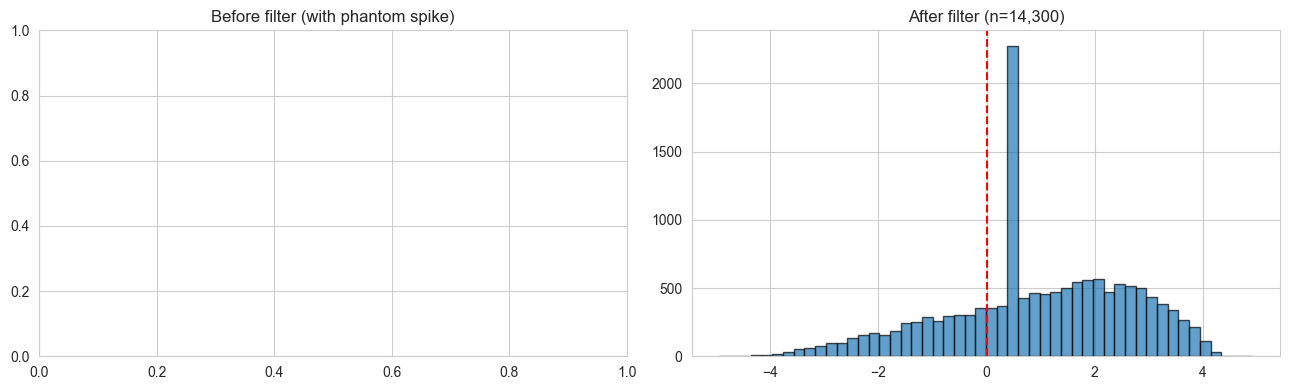

In [6]:
# Optional: side-by-side comparison plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# (You'll need to have saved the pre-filter df_dii first to do this;
# skip if you already overwrote it)
axes[0].set_title('Before filter (with phantom spike)')
axes[1].set_title(f'After filter (n={len(df_dii):,})')
axes[1].hist(df_dii['dii_score'], bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--')
plt.tight_layout(); plt.show()

In [7]:
print(f'df_dr1tot:    {len(df_dr1tot):,}')
print(f'dii_features: {len(dii_features):,}')
print(f'df_dii:       {len(df_dii):,}')

df_dr1tot:    12,392
dii_features: 12,392
df_dii:       14,300


In [9]:
# 1. Confirm df_dr1tot is filtered
print(f'df_dr1tot after filter: {len(df_dr1tot):,}')  # should be 12,392

# 2. Rebuild dii_features from the filtered df_dr1tot
dii_features = pd.DataFrame({'SEQN': df_dr1tot['SEQN']})
for component, nhanes_col in NHANES_COL_MAP.items():
    if nhanes_col is None:
        continue
    if nhanes_col in df_dr1tot.columns:
        dii_features[component] = df_dr1tot[nhanes_col].values
    else:
        dii_features[component] = np.nan

dii_features['caffeine_g'] = dii_features['caffeine_g'] / 1000.0

omega3_cols = [c for c in ['DR1TP183', 'DR1TP205', 'DR1TP225', 'DR1TP226'] if c in df_dr1tot.columns]
omega6_cols = [c for c in ['DR1TP182', 'DR1TP204'] if c in df_dr1tot.columns]
if omega3_cols:
    dii_features['omega3_g'] = df_dr1tot[omega3_cols].sum(axis=1).values
if omega6_cols:
    dii_features['omega6_g'] = df_dr1tot[omega6_cols].sum(axis=1).values

print(f'dii_features rebuilt: {len(dii_features):,}')  # should be 12,392

# 3. Recompute DII scores
dii_scores = dii_features.apply(lambda r: compute_dii_row(r, DII_REF), axis=1)
df_dii = pd.DataFrame({'SEQN': dii_features['SEQN'].values, 'dii_score': dii_scores.values})
print(f'df_dii rebuilt: {len(df_dii):,}')  # should be 12,392
print(df_dii['dii_score'].describe())

# 4. Sanity-check the spike is gone
spike = df_dii['dii_score'].between(0.43, 0.44)
print(f'\nParticipants in old spike region (0.43-0.44): {spike.sum()}')  # should be ~0

df_dr1tot after filter: 12,392
dii_features rebuilt: 12,392
df_dii rebuilt: 12,392
count    12392.000000
mean         1.008468
std          1.812332
min         -4.946304
25%         -0.265659
50%          1.283281
75%          2.451159
max          4.932256
Name: dii_score, dtype: float64

Participants in old spike region (0.43-0.44): 18


In [10]:
# Recompute DII against the filtered dii_features
dii_scores = dii_features.apply(lambda r: compute_dii_row(r, DII_REF), axis=1)
df_dii = pd.DataFrame({
    'SEQN': dii_features['SEQN'].values,
    'dii_score': dii_scores.values
})

print(f'df_dii rebuilt: {len(df_dii):,}')  # should be 12,392
print()
print(df_dii['dii_score'].describe())
print()

# Confirm spike is gone
spike = df_dii['dii_score'].between(0.43, 0.44)
print(f'Participants in old spike region (0.43-0.44): {spike.sum()}')

df_dii rebuilt: 12,392

count    12392.000000
mean         1.008468
std          1.812332
min         -4.946304
25%         -0.265659
50%          1.283281
75%          2.451159
max          4.932256
Name: dii_score, dtype: float64

Participants in old spike region (0.43-0.44): 18


In [11]:
# Re-do the merge with the clean df_dii
df = (df_dii
      .merge(df_demo, on='SEQN', how='inner')
      .merge(df_bmx,  on='SEQN', how='inner')
      .merge(df_crp,  on='SEQN', how='inner'))
df = df.dropna(subset=['dii_score', 'age', 'sex', 'bmi', 'crp_mg_l'])
df = df[df['age'] >= 18].copy()
df['log_crp'] = np.log1p(df['crp_mg_l'])

print(f'Adult cases with all features: {len(df):,}')
print()

# Spearman/Pearson
rho_s, p_s = spearmanr(df['dii_score'], df['crp_mg_l'])
rho_p, p_p = pearsonr(df['dii_score'], df['log_crp'])
print(f'Spearman(DII, CRP):       ρ = {rho_s:+.3f}  (p = {p_s:.2e})')
print(f'Pearson(DII, log(1+CRP)): r = {rho_p:+.3f}  (p = {p_p:.2e})')
print()

# Per-quartile CRP
df['dii_quartile'] = pd.qcut(df['dii_score'], q=4,
                              labels=['Q1 (anti-inflam)', 'Q2', 'Q3', 'Q4 (pro-inflam)'])
print('Per-quartile CRP (mg/L):')
print(df.groupby('dii_quartile')['crp_mg_l'].agg(['mean', 'median', 'count']).round(2))

Adult cases with all features: 7,422

Spearman(DII, CRP):       ρ = +0.138  (p = 4.70e-33)
Pearson(DII, log(1+CRP)): r = +0.144  (p = 1.60e-35)

Per-quartile CRP (mg/L):
                  mean  median  count
dii_quartile                         
Q1 (anti-inflam)  3.01    1.51   1856
Q2                3.89    1.82   1855
Q3                4.33    2.18   1855
Q4 (pro-inflam)   5.07    2.50   1856


In [12]:
X = df[feature_cols].astype(float)
y = df['dii_score'].astype(float)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dii_models = {}
print('Training quantile regressors on clean data...')
for q in QUANTILES:
    model = lgb.LGBMRegressor(
        objective='quantile', alpha=q,
        n_estimators=300, learning_rate=0.05,
        max_depth=5, num_leaves=15, min_child_samples=50,
        random_state=42, verbose=-1,
    )
    model.fit(X_train, y_train)
    dii_models[q] = model
    coverage = (y_test <= model.predict(X_test)).mean()
    print(f'  q={q:.2f}: coverage = {coverage:.3f} (target {q:.3f})')

# Re-save artifacts
for q, model in dii_models.items():
    joblib.dump(model, ARTIFACT_DIR / f'dii_quantile_{int(q*100):02d}.pkl')
print(f'\nArtifacts re-saved to {ARTIFACT_DIR}/')

Training quantile regressors on clean data...
  q=0.10: coverage = 0.119 (target 0.100)
  q=0.25: coverage = 0.266 (target 0.250)
  q=0.50: coverage = 0.537 (target 0.500)
  q=0.75: coverage = 0.755 (target 0.750)
  q=0.90: coverage = 0.888 (target 0.900)
  q=0.95: coverage = 0.938 (target 0.950)
  q=0.99: coverage = 0.981 (target 0.990)

Artifacts re-saved to artifacts\agent2_layer1/


In [18]:
# =============================================================================
# ImmunoSense — Agent 2 (Dietary) — Layer 2: Meal → Nutrient Extraction
#
# Pipeline:  meal text  →  LLM extraction  →  food code matching
#         →  nutrient lookup  →  meal-level nutrient vector
#         →  DII score  →  population percentile (via Layer 1 artifacts)
#
# Default extractor: Claude Haiku 4.5 with prompt caching.
# Swappable interface (Extractor protocol) for future open-source backends.
# Cache format: pickle (avoids pyarrow extension-type conflicts on pandas 3.0).
# =============================================================================

# ---- 1. Setup ----
import os
import re
import unicodedata
from pathlib import Path
from typing import Protocol, Optional
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import joblib
from rapidfuzz import process, fuzz

DATA_DIR = Path('./data/nhanes')
ARTIFACT_DIR = Path('./artifacts/agent2_layer1')   # from Layer 1
CACHE_DIR = Path('./artifacts/agent2_layer2')      # this section
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Load Layer 1 artifacts
dii_models = {}
for q in [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
    dii_models[q] = joblib.load(ARTIFACT_DIR / f'dii_quantile_{int(q*100):02d}.pkl')

layer1_ref = joblib.load(ARTIFACT_DIR / 'dii_scoring_reference.pkl')
DII_REF = layer1_ref['dii_ref']
feature_cols = layer1_ref['feature_cols']

print(f'Layer 1 artifacts loaded: {len(dii_models)} quantile models, {len(DII_REF)} DII components')


# ---- 2. Build the nutrient density cache from NHANES ----
#
# Problem: P_DR1IFF.XPT is 120MB. We don't want to query it per meal.
# Solution: pre-compute average nutrients per 100g per food code, cache as pickle.

NUTRIENT_DENSITY_CACHE = CACHE_DIR / 'nutrient_density_per_100g.pkl'

def build_nutrient_density_cache():
    """One-time pre-computation: food_code → nutrient_per_100g lookup table."""
    if NUTRIENT_DENSITY_CACHE.exists():
        print(f'Cache already exists: {NUTRIENT_DENSITY_CACHE}')
        return pd.read_pickle(NUTRIENT_DENSITY_CACHE)
    
    print('Building nutrient density cache (one-time, ~30s)...')
    df_iff = pd.read_sas(DATA_DIR / 'P_DR1IFF.XPT', format='xport')
    
    # In P_DR1IFF, column prefix is DR1I (per-food-instance), not DR1T (daily total)
    IFF_COL_MAP = {
        'energy_kcal':          'DR1IKCAL',
        'carbohydrate_g':       'DR1ICARB',
        'protein_g':            'DR1IPROT',
        'fat_total_g':          'DR1ITFAT',
        'saturated_fat_g':      'DR1ISFAT',
        'mufa_g':               'DR1IMFAT',
        'pufa_g':               'DR1IPFAT',
        'cholesterol_mg':       'DR1ICHOL',
        'fiber_g':              'DR1IFIBE',
        'vit_a_mcg_rae':        'DR1IVARA',
        'vit_b1_thiamin_mg':    'DR1IVB1',
        'vit_b2_riboflavin_mg': 'DR1IVB2',
        'vit_b3_niacin_mg':     'DR1INIAC',
        'vit_b6_mg':            'DR1IVB6',
        'vit_b12_mcg':          'DR1IVB12',
        'folate_mcg':           'DR1IFOLA',
        'vit_c_mg':             'DR1IVC',
        'vit_d_mcg':            'DR1IVD',
        'vit_e_mg':             'DR1IATOC',
        'iron_mg':              'DR1IIRON',
        'magnesium_mg':         'DR1IMAGN',
        'selenium_mcg':         'DR1ISELE',
        'zinc_mg':              'DR1IZINC',
        'caffeine_g':           'DR1ICAFF',
        'alcohol_g':            'DR1IALCO',
    }
    
    omega3_cols = [c for c in ['DR1IP183', 'DR1IP205', 'DR1IP225', 'DR1IP226'] if c in df_iff.columns]
    omega6_cols = [c for c in ['DR1IP182', 'DR1IP204'] if c in df_iff.columns]
    
    # Reliable recalls only, non-zero gram weights
    df_iff = df_iff[df_iff['DR1DRSTZ'] == 1].copy()
    df_iff = df_iff[df_iff['DR1IGRMS'] > 0].copy()
    
    # Normalize each row to per-100g
    nutrients_per_100g = pd.DataFrame({'food_code': df_iff['DR1IFDCD'].values})
    scale = (100.0 / df_iff['DR1IGRMS']).values
    
    for component, iff_col in IFF_COL_MAP.items():
        if iff_col in df_iff.columns:
            nutrients_per_100g[component] = df_iff[iff_col].values * scale
        else:
            nutrients_per_100g[component] = np.nan
    
    if omega3_cols:
        nutrients_per_100g['omega3_g'] = df_iff[omega3_cols].sum(axis=1).values * scale
    if omega6_cols:
        nutrients_per_100g['omega6_g'] = df_iff[omega6_cols].sum(axis=1).values * scale
    
    # Caffeine: mg → g
    nutrients_per_100g['caffeine_g'] = nutrients_per_100g['caffeine_g'] / 1000.0
    
    # Average per food_code across all instances
    density = nutrients_per_100g.groupby('food_code').mean().reset_index()
    
    # Force clean primitive dtypes
    density['food_code'] = density['food_code'].astype('int64')
    for col in density.columns:
        if col != 'food_code':
            density[col] = pd.to_numeric(density[col], errors='coerce').astype('float64')
    
    density.to_pickle(NUTRIENT_DENSITY_CACHE)
    print(f'  Cached {len(density):,} food codes × {len(density.columns)-1} nutrient components')
    return density

density_df = build_nutrient_density_cache()
print(f'Nutrient density table: {density_df.shape}')


# ---- 3. Build the food code search index ----
#
# Tokenize NHANES food descriptions for fuzzy matching against extracted food names.

FOOD_INDEX_CACHE = CACHE_DIR / 'food_code_search_index.pkl'

def normalize_text(s: str) -> str:
    """lowercase, strip accents and punctuation, collapse whitespace"""
    s = unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode('ascii')
    s = s.lower()
    s = re.sub(r'[^\w\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

def build_food_search_index():
    if FOOD_INDEX_CACHE.exists():
        print(f'Food index cache exists: {FOOD_INDEX_CACHE}')
        return pd.read_pickle(FOOD_INDEX_CACHE)
    
    print('Building food code search index...')
    df_fcd = pd.read_sas(DATA_DIR / 'P_DRXFCD.XPT', format='xport')
    
    # P_DRXFCD: DRXFDCD (food code), DRXFCSD (short desc), DRXFCLD (long desc)
    desc_col = 'DRXFCLD' if 'DRXFCLD' in df_fcd.columns else 'DRXFCSD'
    
    df_fcd['description'] = df_fcd[desc_col].apply(
        lambda x: x.decode('latin-1').strip() if isinstance(x, bytes) else str(x).strip()
    )
    df_fcd['food_code'] = df_fcd['DRXFDCD'].astype(int)
    df_fcd['search_text'] = df_fcd['description'].apply(normalize_text)
    
    index = df_fcd[['food_code', 'description', 'search_text']].copy()
    
    # Keep only codes that exist in the nutrient density table
    index = index[index['food_code'].isin(density_df['food_code'])].copy()
    
    # Force clean dtypes
    index['food_code'] = index['food_code'].astype('int64')
    index['description'] = index['description'].astype(str)
    index['search_text'] = index['search_text'].astype(str)
    
    index.to_pickle(FOOD_INDEX_CACHE)
    print(f'  Indexed {len(index):,} food codes (intersect with nutrient density)')
    return index

food_index = build_food_search_index()
print(f'Food search index: {food_index.shape}')


# ---- 4a. Extractor interface ----

@dataclass
class ExtractedFood:
    name: str                       # what the patient or LLM called it
    portion_g: float                # estimated portion in grams
    portion_confidence: str         # "high" | "default" | "low"

@dataclass
class ExtractedMeal:
    input_text: str
    foods: list[ExtractedFood]
    extraction_warnings: list[str] = field(default_factory=list)

class Extractor(Protocol):
    def extract(self, meal_text: str) -> ExtractedMeal: ...


# ---- 4b. Mock extractor (for offline testing without API key) ----

class MockExtractor:
    """Deterministic toy extractor. Useful for unit-testing the rest of the
    pipeline when ANTHROPIC_API_KEY isn't set. Recognizes a few common foods."""
    
    _RULES = [
        (r'\b(scrambled\s+)?eggs?\b',                'eggs',                  100, 'default'),
        (r'\btoast\b',                                'toast white bread',     50,  'default'),
        (r'\bpasta\b',                                'pasta cooked',          200, 'default'),
        (r'\brice\b',                                 'rice white cooked',     180, 'default'),
        (r'\bchicken\s+(breast|biryani|tikka)?\b',    'chicken breast cooked', 100, 'default'),
        (r'\bsalmon\b',                               'salmon cooked',         120, 'default'),
        (r'\bbanana\b',                               'banana raw',            120, 'default'),
        (r'\bapple\b',                                'apple raw',             150, 'default'),
        (r'\b(coffee|cup\s+of\s+coffee)\b',           'coffee brewed',         240, 'default'),
        (r'\bmilk\b',                                 'milk whole',            240, 'default'),
        (r'\bsalad\b',                                'lettuce salad',         100, 'default'),
        (r'\bavocado\b',                              'avocado raw',           80,  'default'),
        (r'\bdal|lentils?\b',                         'lentils cooked',        150, 'default'),
        (r'\byogurt|raita\b',                         'yogurt plain',          150, 'default'),
    ]
    
    def extract(self, meal_text: str) -> ExtractedMeal:
        text = meal_text.lower()
        foods = []
        for pattern, canonical, portion_g, conf in self._RULES:
            if re.search(pattern, text):
                foods.append(ExtractedFood(name=canonical, portion_g=portion_g, portion_confidence=conf))
        warnings = [] if foods else ['MockExtractor matched no known foods']
        return ExtractedMeal(input_text=meal_text, foods=foods, extraction_warnings=warnings)


# ---- 4c. Claude Haiku 4.5 extractor (production default) ----

class ClaudeHaikuExtractor:
    """LLM extraction with prompt caching. Decomposes meal text into atomic
    foods with portion estimates. Schema-constrained via tool use."""
    
    MODEL = "claude-haiku-4-5"
    
    SYSTEM_PROMPT = """You are a dietary intake extraction system for a clinical \
research pipeline. Your job: decompose free-form meal descriptions into atomic \
food components matching the granularity of the USDA/NHANES food database.

Rules:
1. Decompose composite dishes into atomic ingredients. \
"chicken biryani" → ["cooked basmati rice", "cooked chicken breast", "ghee", \
"fried onions", "mixed spices"]. Do NOT emit "biryani" as a single item.
2. Use generic, search-friendly names. "white bread toast" not "Wonder Bread \
slice". Match what would appear in a dietary database.
3. Estimate portion in grams. If the patient specified a portion ("two slices", \
"one cup"), convert: 1 slice bread ≈ 28g, 1 cup cooked rice ≈ 180g, \
1 cup milk ≈ 240g, 1 medium apple ≈ 180g, 1 medium banana ≈ 120g, \
1 cup cooked pasta ≈ 200g.
4. portion_confidence: "high" when the patient gave an explicit quantity, \
"default" when you used a standard portion, "low" when ambiguous \
("a big bowl", "some chicken").
5. Skip water, condiments under 5g (salt, pepper, herbs as garnish), \
beverages that are pure water.
6. If the meal description is empty, nonsensical, or not food, return an empty \
foods list.

Output via the extract_foods tool. Never respond in free text."""

    TOOL_SCHEMA = {
        "name": "extract_foods",
        "description": "Emit the decomposed atomic food list for the meal.",
        "input_schema": {
            "type": "object",
            "properties": {
                "foods": {
                    "type": "array",
                    "items": {
                        "type": "object",
                        "properties": {
                            "name": {"type": "string"},
                            "portion_g": {"type": "number"},
                            "portion_confidence": {
                                "type": "string",
                                "enum": ["high", "default", "low"]
                            }
                        },
                        "required": ["name", "portion_g", "portion_confidence"]
                    }
                }
            },
            "required": ["foods"]
        }
    }
    
    def __init__(self, api_key: Optional[str] = None):
        import anthropic
        self.client = anthropic.Anthropic(api_key=api_key or os.environ.get('ANTHROPIC_API_KEY'))
    
    def extract(self, meal_text: str) -> ExtractedMeal:
        try:
            response = self.client.messages.create(
                model=self.MODEL,
                max_tokens=1024,
                system=[
                    {
                        "type": "text",
                        "text": self.SYSTEM_PROMPT,
                        "cache_control": {"type": "ephemeral"}
                    }
                ],
                tools=[self.TOOL_SCHEMA],
                tool_choice={"type": "tool", "name": "extract_foods"},
                messages=[{"role": "user", "content": meal_text}],
            )
        except Exception as e:
            return ExtractedMeal(
                input_text=meal_text, foods=[],
                extraction_warnings=[f'API call failed: {type(e).__name__}: {e}']
            )
        
        tool_block = next((b for b in response.content if b.type == 'tool_use'), None)
        if tool_block is None:
            return ExtractedMeal(
                input_text=meal_text, foods=[],
                extraction_warnings=['LLM did not emit a tool_use block']
            )
        
        foods = [
            ExtractedFood(
                name=f['name'],
                portion_g=float(f['portion_g']),
                portion_confidence=f['portion_confidence']
            )
            for f in tool_block.input.get('foods', [])
        ]
        return ExtractedMeal(input_text=meal_text, foods=foods, extraction_warnings=[])


# ---- 4d. Choose default extractor based on environment ----

def make_default_extractor() -> Extractor:
    if os.environ.get('ANTHROPIC_API_KEY'):
        try:
            import anthropic   # noqa
            print('Default extractor: ClaudeHaikuExtractor (with prompt caching)')
            return ClaudeHaikuExtractor()
        except ImportError:
            print('anthropic package not installed; falling back to MockExtractor')
    else:
        print('ANTHROPIC_API_KEY not set; using MockExtractor')
    return MockExtractor()

extractor = make_default_extractor()

Layer 1 artifacts loaded: 7 quantile models, 27 DII components
Building nutrient density cache (one-time, ~30s)...
  Cached 5,254 food codes × 27 nutrient components
Nutrient density table: (5254, 28)
Building food code search index...
  Indexed 5,254 food codes (intersect with nutrient density)
Food search index: (5254, 3)
ANTHROPIC_API_KEY not set; using MockExtractor


In [24]:
# =============================================================================
# ImmunoSense — Agent 2 (Dietary) — Layer 2: Meal → Nutrient Vector  [LOCKED]
#
# Architecture:
#   meal text → LLM extraction → NHANES fuzzy match → nutrient lookup
#              → trigger classification → daily rollup → 12-feature vector
#
# Layer 3 contract — 12 daily features:
#   dii_score, omega6_omega3_ratio, glycemic_load, sodium_mg, alcohol_g,
#   first_meal_timestamp, last_meal_timestamp, longest_intraday_gap_hours,
#   gluten_present, dairy_present, nightshade_present, upf_present
#
# DII is intentionally computed only at daily granularity. Overnight fasting
# is computed by Layer 3 across days, using today.first_meal_timestamp and
# yesterday.last_meal_timestamp.
# =============================================================================

# ---- 1. Setup ----
import os
import re
import unicodedata
from pathlib import Path
from typing import Protocol, Optional
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import joblib
from scipy.stats import norm
from rapidfuzz import process, fuzz

DATA_DIR = Path('./data/nhanes')
ARTIFACT_DIR = Path('./artifacts/agent2_layer1')   # from Layer 1
CACHE_DIR = Path('./artifacts/agent2_layer2')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Load Layer 1 artifacts (quantile regressors + DII reference)
dii_models = {}
for q in [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
    dii_models[q] = joblib.load(ARTIFACT_DIR / f'dii_quantile_{int(q*100):02d}.pkl')

layer1_ref = joblib.load(ARTIFACT_DIR / 'dii_scoring_reference.pkl')
DII_REF = layer1_ref['dii_ref']
feature_cols = layer1_ref['feature_cols']

print(f'Layer 1 artifacts loaded: {len(dii_models)} quantile models, {len(DII_REF)} DII components')


# ---- 2. Nutrient density cache (per-100g lookup, includes sodium) ----

NUTRIENT_DENSITY_CACHE = CACHE_DIR / 'nutrient_density_per_100g_v2.pkl'

def build_nutrient_density_cache():
    if NUTRIENT_DENSITY_CACHE.exists():
        print(f'Cache exists: {NUTRIENT_DENSITY_CACHE}')
        return pd.read_pickle(NUTRIENT_DENSITY_CACHE)
    
    print('Building nutrient density cache (one-time, ~30s)...')
    df_iff = pd.read_sas(DATA_DIR / 'P_DR1IFF.XPT', format='xport')
    
    IFF_COL_MAP = {
        'energy_kcal':          'DR1IKCAL',
        'carbohydrate_g':       'DR1ICARB',
        'protein_g':            'DR1IPROT',
        'fat_total_g':          'DR1ITFAT',
        'saturated_fat_g':      'DR1ISFAT',
        'mufa_g':               'DR1IMFAT',
        'pufa_g':               'DR1IPFAT',
        'cholesterol_mg':       'DR1ICHOL',
        'fiber_g':              'DR1IFIBE',
        'vit_a_mcg_rae':        'DR1IVARA',
        'vit_b1_thiamin_mg':    'DR1IVB1',
        'vit_b2_riboflavin_mg': 'DR1IVB2',
        'vit_b3_niacin_mg':     'DR1INIAC',
        'vit_b6_mg':            'DR1IVB6',
        'vit_b12_mcg':          'DR1IVB12',
        'folate_mcg':           'DR1IFOLA',
        'vit_c_mg':             'DR1IVC',
        'vit_d_mcg':            'DR1IVD',
        'vit_e_mg':             'DR1IATOC',
        'iron_mg':              'DR1IIRON',
        'magnesium_mg':         'DR1IMAGN',
        'selenium_mcg':         'DR1ISELE',
        'zinc_mg':              'DR1IZINC',
        'caffeine_g':           'DR1ICAFF',
        'alcohol_g':            'DR1IALCO',
        'sodium_mg':            'DR1ISODI',     # Layer 3 Th17 driver
    }
    
    omega3_cols = [c for c in ['DR1IP183', 'DR1IP205', 'DR1IP225', 'DR1IP226'] if c in df_iff.columns]
    omega6_cols = [c for c in ['DR1IP182', 'DR1IP204'] if c in df_iff.columns]
    
    df_iff = df_iff[df_iff['DR1DRSTZ'] == 1].copy()
    df_iff = df_iff[df_iff['DR1IGRMS'] > 0].copy()
    
    nutrients_per_100g = pd.DataFrame({'food_code': df_iff['DR1IFDCD'].values})
    scale = (100.0 / df_iff['DR1IGRMS']).values
    
    for component, iff_col in IFF_COL_MAP.items():
        if iff_col in df_iff.columns:
            nutrients_per_100g[component] = df_iff[iff_col].values * scale
        else:
            nutrients_per_100g[component] = np.nan
    
    if omega3_cols:
        nutrients_per_100g['omega3_g'] = df_iff[omega3_cols].sum(axis=1).values * scale
    if omega6_cols:
        nutrients_per_100g['omega6_g'] = df_iff[omega6_cols].sum(axis=1).values * scale
    
    nutrients_per_100g['caffeine_g'] = nutrients_per_100g['caffeine_g'] / 1000.0
    
    density = nutrients_per_100g.groupby('food_code').mean().reset_index()
    density['food_code'] = density['food_code'].astype('int64')
    for col in density.columns:
        if col != 'food_code':
            density[col] = pd.to_numeric(density[col], errors='coerce').astype('float64')
    
    density.to_pickle(NUTRIENT_DENSITY_CACHE)
    print(f'  Cached {len(density):,} food codes × {len(density.columns)-1} components')
    return density

density_df = build_nutrient_density_cache()
_density_by_code = density_df.set_index('food_code')
print(f'Nutrient density table: {density_df.shape}')


# ---- 3. Food code search index ----

FOOD_INDEX_CACHE = CACHE_DIR / 'food_code_search_index.pkl'

def normalize_text(s: str) -> str:
    s = unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode('ascii')
    s = s.lower()
    s = re.sub(r'[^\w\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

def build_food_search_index():
    if FOOD_INDEX_CACHE.exists():
        print(f'Food index cache exists: {FOOD_INDEX_CACHE}')
        return pd.read_pickle(FOOD_INDEX_CACHE)
    
    print('Building food code search index...')
    df_fcd = pd.read_sas(DATA_DIR / 'P_DRXFCD.XPT', format='xport')
    
    desc_col = 'DRXFCLD' if 'DRXFCLD' in df_fcd.columns else 'DRXFCSD'
    df_fcd['description'] = df_fcd[desc_col].apply(
        lambda x: x.decode('latin-1').strip() if isinstance(x, bytes) else str(x).strip()
    )
    df_fcd['food_code'] = df_fcd['DRXFDCD'].astype(int)
    df_fcd['search_text'] = df_fcd['description'].apply(normalize_text)
    
    index = df_fcd[['food_code', 'description', 'search_text']].copy()
    index = index[index['food_code'].isin(density_df['food_code'])].copy()
    
    index['food_code'] = index['food_code'].astype('int64')
    index['description'] = index['description'].astype(str)
    index['search_text'] = index['search_text'].astype(str)
    
    index.to_pickle(FOOD_INDEX_CACHE)
    print(f'  Indexed {len(index):,} food codes')
    return index

food_index = build_food_search_index()
_food_corpus = food_index['search_text'].tolist()
_food_code_array = food_index['food_code'].values
print(f'Food search index: {food_index.shape}')


# ---- 4. Extractor interface + Mock + Claude Haiku ----

@dataclass
class ExtractedFood:
    name: str
    portion_g: float
    portion_confidence: str            # "high" | "default" | "low"

@dataclass
class ExtractedMeal:
    input_text: str
    foods: list[ExtractedFood]
    extraction_warnings: list[str] = field(default_factory=list)

class Extractor(Protocol):
    def extract(self, meal_text: str) -> ExtractedMeal: ...


class MockExtractor:
    """Deterministic offline extractor for testing without API key."""
    _RULES = [
        (r'\b(scrambled\s+)?eggs?\b',                'eggs',                  100, 'default'),
        (r'\btoast\b',                                'toast white bread',     50,  'default'),
        (r'\bpasta\b',                                'pasta cooked',          200, 'default'),
        (r'\brice\b',                                 'rice white cooked',     180, 'default'),
        (r'\bchicken(\s+(breast|biryani|tikka))?\b',  'chicken breast cooked', 100, 'default'),
        (r'\bsalmon\b',                               'salmon cooked',         120, 'default'),
        (r'\bbanana\b',                               'banana raw',            120, 'default'),
        (r'\bapple\b',                                'apple raw',             150, 'default'),
        (r'\b(coffee|cup\s+of\s+coffee)\b',           'coffee brewed',         240, 'default'),
        (r'\bmilk\b',                                 'milk whole',            240, 'default'),
        (r'\bsalad\b',                                'lettuce salad',         100, 'default'),
        (r'\bavocado\b',                              'avocado raw',           80,  'default'),
        (r'\b(dal|lentils?)\b',                       'lentils cooked',        150, 'default'),
        (r'\b(yogurt|raita)\b',                       'yogurt plain',          150, 'default'),
        (r'\b(soda|cola)\b',                          'cola soda',             355, 'default'),
        (r'\b(hot\s+dog|sausage|bacon)\b',            'sausage cooked',        50,  'default'),
        (r'\b(potato|french\s+fries|fries)\b',        'potato cooked',         150, 'default'),
        (r'\btomato\b',                               'tomato raw',            100, 'default'),
        (r'\b(beer|wine|whiskey|vodka)\b',            'beer',                  355, 'default'),
    ]
    
    def extract(self, meal_text: str) -> ExtractedMeal:
        text = meal_text.lower()
        foods = []
        for pattern, canonical, portion_g, conf in self._RULES:
            if re.search(pattern, text):
                foods.append(ExtractedFood(name=canonical, portion_g=portion_g, portion_confidence=conf))
        warnings = [] if foods else ['MockExtractor matched no known foods']
        return ExtractedMeal(input_text=meal_text, foods=foods, extraction_warnings=warnings)


class ClaudeHaikuExtractor:
    """Production extractor: Claude Haiku 4.5 with prompt caching."""
    
    MODEL = "claude-haiku-4-5"
    
    SYSTEM_PROMPT = """You are a dietary intake extraction system for a clinical \
research pipeline. Your job: decompose free-form meal descriptions into atomic \
food components matching the granularity of the USDA/NHANES food database.

Rules:
1. Decompose composite dishes into atomic ingredients. \
"chicken biryani" → ["cooked basmati rice", "cooked chicken breast", "ghee", \
"fried onions", "mixed spices"]. Do NOT emit "biryani" as a single item.
2. Use generic, search-friendly names. "white bread toast" not "Wonder Bread \
slice". Match what would appear in a dietary database.
3. Estimate portion in grams. If the patient specified a portion ("two slices", \
"one cup"), convert: 1 slice bread ≈ 28g, 1 cup cooked rice ≈ 180g, \
1 cup milk ≈ 240g, 1 medium apple ≈ 180g, 1 medium banana ≈ 120g, \
1 cup cooked pasta ≈ 200g, 1 can soda ≈ 355g, 1 beer ≈ 355g, 1 glass wine ≈ 150g.
4. portion_confidence: "high" when patient gave explicit quantity, "default" \
when you used a standard portion, "low" when ambiguous ("a big bowl", "some chicken").
5. Skip water, condiments under 5g (salt, pepper, herbs as garnish), beverages \
that are pure water.
6. If meal description is empty, nonsensical, or not food, return an empty foods list.

Output via the extract_foods tool. Never respond in free text."""

    TOOL_SCHEMA = {
        "name": "extract_foods",
        "description": "Emit the decomposed atomic food list for the meal.",
        "input_schema": {
            "type": "object",
            "properties": {
                "foods": {
                    "type": "array",
                    "items": {
                        "type": "object",
                        "properties": {
                            "name": {"type": "string"},
                            "portion_g": {"type": "number"},
                            "portion_confidence": {
                                "type": "string",
                                "enum": ["high", "default", "low"]
                            }
                        },
                        "required": ["name", "portion_g", "portion_confidence"]
                    }
                }
            },
            "required": ["foods"]
        }
    }
    
    def __init__(self, api_key: Optional[str] = None):
        import anthropic
        self.client = anthropic.Anthropic(api_key=api_key or os.environ.get('ANTHROPIC_API_KEY'))
    
    def extract(self, meal_text: str) -> ExtractedMeal:
        try:
            response = self.client.messages.create(
                model=self.MODEL,
                max_tokens=1024,
                system=[{
                    "type": "text",
                    "text": self.SYSTEM_PROMPT,
                    "cache_control": {"type": "ephemeral"}
                }],
                tools=[self.TOOL_SCHEMA],
                tool_choice={"type": "tool", "name": "extract_foods"},
                messages=[{"role": "user", "content": meal_text}],
            )
        except Exception as e:
            return ExtractedMeal(
                input_text=meal_text, foods=[],
                extraction_warnings=[f'API call failed: {type(e).__name__}: {e}']
            )
        
        tool_block = next((b for b in response.content if b.type == 'tool_use'), None)
        if tool_block is None:
            return ExtractedMeal(
                input_text=meal_text, foods=[],
                extraction_warnings=['LLM did not emit a tool_use block']
            )
        
        foods = [
            ExtractedFood(
                name=f['name'],
                portion_g=float(f['portion_g']),
                portion_confidence=f['portion_confidence']
            )
            for f in tool_block.input.get('foods', [])
        ]
        return ExtractedMeal(input_text=meal_text, foods=foods, extraction_warnings=[])


def make_default_extractor() -> Extractor:
    if os.environ.get('ANTHROPIC_API_KEY'):
        try:
            import anthropic   # noqa
            print('Default extractor: ClaudeHaikuExtractor (with prompt caching)')
            return ClaudeHaikuExtractor()
        except ImportError:
            print('anthropic package not installed; falling back to MockExtractor')
    else:
        print('ANTHROPIC_API_KEY not set; using MockExtractor')
    return MockExtractor()

extractor = make_default_extractor()


# ---- 5. Food code matcher (prefix-anchored + WRatio) ----

@dataclass
class FoodMatch:
    extracted_name: str
    nhanes_code: int
    nhanes_description: str
    match_score: float

def match_food(extracted_name: str, min_score: float = 70.0) -> Optional[FoodMatch]:
    """Fuzzy match extracted food → NHANES code.
    Stage 1: prefix-anchored within first-word stem.
    Stage 2: global fuzzy fallback. WRatio for discriminating short queries."""
    
    query = normalize_text(extracted_name)
    if not query:
        return None
    
    first_word = query.split()[0]
    
    # Stage 1: prefix-anchored
    stems = {first_word}
    if first_word.endswith('s') and len(first_word) > 3:
        stems.add(first_word[:-1])
    
    prefix_mask = food_index['search_text'].str.split().str[0].isin(stems)
    candidates = food_index[prefix_mask]
    
    if len(candidates) > 0:
        corpus = candidates['search_text'].tolist()
        codes = candidates['food_code'].values
        descs = candidates['description'].values
        
        result = process.extractOne(query, corpus, scorer=fuzz.WRatio)
        if result is not None:
            text, score, idx = result
            if score >= min_score:
                return FoodMatch(
                    extracted_name=extracted_name,
                    nhanes_code=int(codes[idx]),
                    nhanes_description=str(descs[idx]),
                    match_score=float(score),
                )
    
    # Stage 2: global fallback
    result = process.extractOne(query, _food_corpus, scorer=fuzz.WRatio)
    if result is None:
        return None
    text, score, idx = result
    if score < min_score:
        return None
    
    return FoodMatch(
        extracted_name=extracted_name,
        nhanes_code=int(_food_code_array[idx]),
        nhanes_description=str(food_index.iloc[idx]['description']),
        match_score=float(score),
    )


# ---- 6. Trigger classification + glycemic load lookup ----

DAIRY_FIRST_DIGITS = {1}
DAIRY_KEYWORDS = {'milk', 'cheese', 'yogurt', 'butter', 'cream', 'ice cream',
                  'cottage', 'ricotta', 'feta', 'mozzarella', 'cheddar',
                  'whey', 'casein', 'kefir', 'ghee'}

GLUTEN_FIRST_DIGITS = {5}
GLUTEN_KEYWORDS = {'wheat', 'flour', 'bread', 'pasta', 'noodle', 'cracker',
                   'cereal', 'oat', 'barley', 'rye', 'bulgur', 'couscous',
                   'tortilla', 'pizza', 'cake', 'cookie', 'muffin', 'pancake',
                   'waffle', 'pretzel', 'crouton', 'biscuit', 'pastry',
                   'spaghetti', 'macaroni', 'ravioli'}
GLUTEN_FREE_KEYWORDS = {'rice', 'corn', 'quinoa', 'millet', 'buckwheat',
                        'sorghum', 'amaranth', 'gluten free', 'gluten-free'}

NIGHTSHADE_KEYWORDS = {'tomato', 'potato', 'eggplant', 'pepper', 'bell pepper',
                       'paprika', 'cayenne', 'chili', 'chile', 'goji',
                       'tomatillo', 'pimento', 'pimiento'}
NIGHTSHADE_EXCLUSIONS = {'sweet potato', 'yam'}

UPF_KEYWORDS = {
    'cookie', 'cake', 'muffin', 'pastry', 'donut', 'doughnut', 'brownie',
    'twinkie', 'pop tart', 'pop-tart', 'snack cake',
    'hot dog', 'sausage', 'bologna', 'salami', 'pepperoni', 'bacon',
    'spam', 'luncheon meat', 'chicken nugget', 'fish stick', 'corn dog',
    'soda', 'cola', 'soft drink', 'energy drink', 'sports drink',
    'sweetened beverage', 'fruit drink',
    'frozen meal', 'frozen pizza', 'frozen dinner', 'instant noodle',
    'macaroni and cheese', 'instant soup',
    'chip', 'crisp', 'cheez', 'goldfish',
    'candy', 'chocolate bar', 'gummy', 'marshmallow',
}

GI_BY_CATEGORY = {
    'white rice': 73, 'rice': 73,
    'white bread': 75, 'bread': 70, 'toast': 70,
    'baked potato': 85, 'mashed potato': 85, 'potato': 78, 'french fries': 75,
    'corn flakes': 81, 'instant oat': 79,
    'soda': 65, 'cola': 65,
    'cake': 70, 'cookie': 65, 'donut': 75,
    'brown rice': 68, 'pasta': 50, 'oat': 55, 'oatmeal': 55,
    'banana': 51, 'mango': 51, 'pineapple': 59,
    'apple': 36, 'pear': 38, 'orange': 43, 'grape': 53,
    'milk': 31, 'yogurt': 35,
    'lentil': 32, 'lentils': 32, 'dal': 32, 'bean': 30, 'beans': 30,
    'chickpea': 28,
    'broccoli': 15, 'spinach': 15, 'lettuce': 15, 'salad': 15,
    'avocado': 15, 'tomato': 15, 'cucumber': 15,
    'egg': 0, 'eggs': 0,
    'chicken': 0, 'beef': 0, 'pork': 0, 'fish': 0, 'salmon': 0, 'tuna': 0,
    'nut': 15, 'almond': 15, 'walnut': 15,
    'coffee': 0, 'tea': 0, 'water': 0,
    'beer': 25, 'wine': 0,
}
DEFAULT_GI = 50

def _desc_contains(desc_norm: str, keyword_set: set) -> bool:
    return any(kw in desc_norm for kw in keyword_set)

def classify_food_triggers(nhanes_code: int, description: str) -> dict:
    """Per-food: returns {dairy, gluten, nightshade, upf} bools + estimated_gi."""
    desc_norm = normalize_text(description)
    first_digit = int(str(nhanes_code)[0]) if nhanes_code > 0 else 0
    
    dairy = (first_digit in DAIRY_FIRST_DIGITS) or _desc_contains(desc_norm, DAIRY_KEYWORDS)
    
    has_gluten_kw = _desc_contains(desc_norm, GLUTEN_KEYWORDS)
    has_gf_kw = _desc_contains(desc_norm, GLUTEN_FREE_KEYWORDS)
    gluten = (first_digit in GLUTEN_FIRST_DIGITS or has_gluten_kw) and not has_gf_kw
    if 'gluten free' in desc_norm or 'gluten-free' in desc_norm:
        gluten = False
    
    nightshade = (_desc_contains(desc_norm, NIGHTSHADE_KEYWORDS) and 
                  not _desc_contains(desc_norm, NIGHTSHADE_EXCLUSIONS))
    
    upf = _desc_contains(desc_norm, UPF_KEYWORDS)
    
    gi = DEFAULT_GI
    matched_kw = ''
    for kw, gi_val in GI_BY_CATEGORY.items():
        if kw in desc_norm and len(kw) > len(matched_kw):
            gi = gi_val
            matched_kw = kw
    
    return {'dairy': dairy, 'gluten': gluten, 'nightshade': nightshade,
            'upf': upf, 'estimated_gi': gi}


# ---- 7. DII scoring + Layer 1 percentile lookup ----

def compute_meal_dii(nutrients: dict, ref: dict = DII_REF) -> float:
    """Shivappa scoring. Apply only to DAILY nutrient vector — not per-meal."""
    total = 0.0
    n_used = 0
    for component, (mu, sd, effect) in ref.items():
        v = nutrients.get(component)
        if v is None or pd.isna(v):
            continue
        z = (v - mu) / sd
        centered = (norm.cdf(z) * 2.0) - 1.0
        total += centered * effect
        n_used += 1
    return total if n_used > 0 else float('nan')

def get_dii_percentile(age: float, sex: int, bmi: float, dii_value: float) -> float:
    """Place a daily DII on the demographic-specific population distribution."""
    X_one = pd.DataFrame([[age, sex, bmi]], columns=feature_cols)
    qs = np.array(list(dii_models.keys()))
    vs = np.array([float(m.predict(X_one)[0]) for m in dii_models.values()])
    order = np.argsort(vs)
    qs, vs = qs[order], vs[order]
    if dii_value <= vs[0]:  return float(qs[0])
    if dii_value >= vs[-1]: return float(qs[-1])
    return float(np.interp(dii_value, vs, qs))


# ---- 8. Per-meal pipeline (nutrient vector + triggers + GL — NO DII) ----

@dataclass
class MealResult:
    input_text: str
    timestamp: Optional[str]
    extracted_foods: list[ExtractedFood]
    matches: list[Optional[FoodMatch]]
    nutrients: dict
    triggers: dict
    glycemic_load: float
    n_foods_extracted: int
    n_foods_matched: int
    n_foods_unmatched: int
    warnings: list[str]

def process_meal(meal_text: str, extractor: Extractor = extractor,
                 timestamp: Optional[str] = None) -> MealResult:
    """Per-meal: text → nutrients + triggers + GL. NO DII at this granularity."""
    
    extracted = extractor.extract(meal_text)
    warnings = list(extracted.extraction_warnings)
    
    components = list(DII_REF.keys()) + ['sodium_mg']
    nutrients = {c: 0.0 for c in components}
    triggers = {'dairy': False, 'gluten': False, 'nightshade': False, 'upf': False}
    glycemic_load = 0.0
    
    if not extracted.foods:
        return MealResult(
            input_text=meal_text, timestamp=timestamp,
            extracted_foods=[], matches=[],
            nutrients=nutrients, triggers=triggers, glycemic_load=0.0,
            n_foods_extracted=0, n_foods_matched=0, n_foods_unmatched=0,
            warnings=warnings + ['No foods extracted'],
        )
    
    matches = [match_food(f.name) for f in extracted.foods]
    n_matched = sum(1 for m in matches if m is not None)
    n_unmatched = len(matches) - n_matched
    
    for f, m in zip(extracted.foods, matches):
        if m is None:
            warnings.append(f'No NHANES match for: {f.name}')
        elif m.match_score < 75:
            warnings.append(f'Low-confidence match ({m.match_score:.0f}): {f.name} → {m.nhanes_description[:50]}')
    
    for food, match in zip(extracted.foods, matches):
        if match is None:
            continue
        try:
            density_row = _density_by_code.loc[match.nhanes_code]
        except KeyError:
            warnings.append(f'NHANES code {match.nhanes_code} has no nutrient data')
            continue
        
        scale_factor = food.portion_g / 100.0
        for c in components:
            v = density_row.get(c)
            if pd.notna(v):
                nutrients[c] += float(v) * scale_factor
        
        cls = classify_food_triggers(match.nhanes_code, match.nhanes_description)
        for trig in triggers:
            if cls[trig]:
                triggers[trig] = True
        
        carb_in_meal = float(density_row.get('carbohydrate_g', 0) or 0) * scale_factor
        glycemic_load += (carb_in_meal * cls['estimated_gi']) / 100.0
    
    return MealResult(
        input_text=meal_text, timestamp=timestamp,
        extracted_foods=extracted.foods, matches=matches,
        nutrients=nutrients, triggers=triggers, glycemic_load=glycemic_load,
        n_foods_extracted=len(extracted.foods),
        n_foods_matched=n_matched, n_foods_unmatched=n_unmatched,
        warnings=warnings,
    )


# ---- 9. Daily rollup → 12-feature vector for Layer 3 ----

@dataclass
class DailyRollup:
    date: str
    meal_count: int
    daily_nutrients: dict
    
    # The Layer-3-facing feature vector (12 features)
    dii_score: float
    omega6_omega3_ratio: float
    glycemic_load: float
    sodium_mg: float
    alcohol_g: float
    
    # Timestamps for Layer 3 to compute cross-day overnight fast
    first_meal_timestamp: Optional[str]    # ISO8601 of earliest meal today
    last_meal_timestamp: Optional[str]     # ISO8601 of latest meal today
    longest_intraday_gap_hours: float      # within-day max gap (NOT overnight fast)
    
    gluten_present: bool
    dairy_present: bool
    nightshade_present: bool
    upf_present: bool
    
    feature_confidence: dict
    daily_dii_percentile: Optional[float]
    meal_results: list


def compute_intraday_gap_and_timestamps(meal_results: list):
    """Returns (first_ts, last_ts, longest_intraday_gap_hours).
    
    Note: this is the longest gap WITHIN a single day, not the overnight fast.
    Overnight fasting (the autoimmune-relevant metric) is computed in Layer 3
    using first_meal_timestamp of today and last_meal_timestamp of yesterday.
    """
    timed = [m for m in meal_results if m.timestamp is not None]
    if not timed:
        return None, None, float('nan')
    
    timestamps = []
    for m in timed:
        try:
            timestamps.append(pd.Timestamp(m.timestamp))
        except Exception:
            pass
    
    if not timestamps:
        return None, None, float('nan')
    
    timestamps.sort()
    first_ts = timestamps[0].isoformat()
    last_ts = timestamps[-1].isoformat()
    
    if len(timestamps) < 2:
        return first_ts, last_ts, float('nan')
    
    gaps = [(timestamps[i+1] - timestamps[i]).total_seconds() / 3600.0
            for i in range(len(timestamps) - 1)]
    return first_ts, last_ts, float(max(gaps))


def rollup_day(meal_results: list, date: str,
               age: Optional[float] = None, sex: Optional[int] = None,
               bmi: Optional[float] = None) -> DailyRollup:
    """Aggregate a day's meals into the 12-feature Layer 3 vector.
    
    Note: overnight/true fasting window is computed by Layer 3 across days,
    using first_meal_timestamp (today) and last_meal_timestamp (yesterday).
    """
    
    components = list(DII_REF.keys()) + ['sodium_mg']
    daily = {c: 0.0 for c in components}
    triggers = {'dairy': False, 'gluten': False, 'nightshade': False, 'upf': False}
    glycemic_load = 0.0
    
    for mr in meal_results:
        for c in components:
            daily[c] += mr.nutrients.get(c, 0.0)
        for trig in triggers:
            if mr.triggers.get(trig, False):
                triggers[trig] = True
        glycemic_load += mr.glycemic_load
    
    daily_dii = compute_meal_dii(daily)
    
    o3 = daily.get('omega3_g', 0.0)
    o6 = daily.get('omega6_g', 0.0)
    ratio = (o6 / o3) if o3 > 1e-6 else float('nan')
    
    first_ts, last_ts, gap = compute_intraday_gap_and_timestamps(meal_results)
    
    percentile = None
    if age is not None and sex is not None and bmi is not None and not pd.isna(daily_dii):
        percentile = get_dii_percentile(age, sex, bmi, daily_dii)
    
    feature_confidence = {
        'dii_score': 'high',
        'omega6_omega3_ratio': 'high',
        'sodium_mg': 'high',
        'alcohol_g': 'high',
        'glycemic_load': 'medium',
        'longest_intraday_gap_hours': 'medium' if not pd.isna(gap) else 'unavailable',
        'first_meal_timestamp': 'high' if first_ts else 'unavailable',
        'last_meal_timestamp': 'high' if last_ts else 'unavailable',
        'gluten_present': 'medium',
        'dairy_present': 'medium',
        'nightshade_present': 'medium',
        'upf_present': 'low',
    }
    
    return DailyRollup(
        date=date,
        meal_count=len(meal_results),
        daily_nutrients=daily,
        dii_score=daily_dii,
        omega6_omega3_ratio=ratio,
        glycemic_load=glycemic_load,
        sodium_mg=daily.get('sodium_mg', 0.0),
        alcohol_g=daily.get('alcohol_g', 0.0),
        first_meal_timestamp=first_ts,
        last_meal_timestamp=last_ts,
        longest_intraday_gap_hours=gap,
        gluten_present=triggers['gluten'],
        dairy_present=triggers['dairy'],
        nightshade_present=triggers['nightshade'],
        upf_present=triggers['upf'],
        feature_confidence=feature_confidence,
        daily_dii_percentile=percentile,
        meal_results=meal_results,
    )


# ---- 10. Smoke test ----

print('\n' + '='*70)
print('Layer 2 daily-rollup smoke test (12-feature vector)')
print('='*70)

patient = {'age': 45, 'sex': 2, 'bmi': 28}

day_meals = [
    process_meal("Two scrambled eggs and toast", timestamp='2026-05-22T08:00:00'),
    process_meal("Chicken with rice and salad", timestamp='2026-05-22T12:30:00'),
    process_meal("An apple as a snack", timestamp='2026-05-22T15:00:00'),
    process_meal("Salmon with rice, avocado on the side", timestamp='2026-05-22T19:00:00'),
]

day = rollup_day(day_meals, date='2026-05-22', **patient)

print(f'\nPatient: {patient}')
print(f'Date: {day.date} | meals: {day.meal_count}\n')

print('--- Layer 3 feature vector ---')
print(f'  dii_score:                   {day.dii_score:+.2f}')
pct_str = f'{day.daily_dii_percentile:.0%}' if day.daily_dii_percentile is not None else 'n/a'
print(f'  dii_percentile:              {pct_str}')
print(f'  omega6_omega3_ratio:         {day.omega6_omega3_ratio:.2f}')
print(f'  glycemic_load:               {day.glycemic_load:.1f}')
print(f'  sodium_mg:                   {day.sodium_mg:.0f}')
print(f'  alcohol_g:                   {day.alcohol_g:.1f}')
print(f'  first_meal_timestamp:        {day.first_meal_timestamp}')
print(f'  last_meal_timestamp:         {day.last_meal_timestamp}')
print(f'  longest_intraday_gap_hours:  {day.longest_intraday_gap_hours:.1f}')
print(f'  gluten_present:              {day.gluten_present}')
print(f'  dairy_present:               {day.dairy_present}')
print(f'  nightshade_present:          {day.nightshade_present}')
print(f'  upf_present:                 {day.upf_present}')

print('\n--- Feature confidence (for Layer 3 weighting) ---')
for f, c in day.feature_confidence.items():
    print(f'  {f:30s} {c}')

print('\n--- Selected daily nutrient totals (traceability) ---')
print(f'  Energy:       {day.daily_nutrients["energy_kcal"]:>7.0f} kcal')
print(f'  Protein:      {day.daily_nutrients["protein_g"]:>7.1f} g')
print(f'  Fat total:    {day.daily_nutrients["fat_total_g"]:>7.1f} g')
print(f'  Fiber:        {day.daily_nutrients["fiber_g"]:>7.1f} g')
print(f'  Omega-3:      {day.daily_nutrients["omega3_g"]:>7.2f} g')
print(f'  Omega-6:      {day.daily_nutrients["omega6_g"]:>7.2f} g')
print(f'  Sodium:       {day.daily_nutrients["sodium_mg"]:>7.0f} mg')

print('\n' + '='*70)
print('Layer 2 complete. Output contract LOCKED for Layer 3.')
print('Layer-3-facing fields: dii_score, omega6_omega3_ratio, glycemic_load,')
print('  sodium_mg, alcohol_g, first_meal_timestamp, last_meal_timestamp,')
print('  longest_intraday_gap_hours, gluten_present, dairy_present,')
print('  nightshade_present, upf_present (+ daily_dii_percentile context)')
print('Next: Layer 3 — robust tracker + per-patient pattern detection.')
print('='*70)

Layer 1 artifacts loaded: 7 quantile models, 27 DII components
Cache exists: artifacts\agent2_layer2\nutrient_density_per_100g_v2.pkl
Nutrient density table: (5254, 29)
Food index cache exists: artifacts\agent2_layer2\food_code_search_index.pkl
Food search index: (5254, 3)
ANTHROPIC_API_KEY not set; using MockExtractor

Layer 2 daily-rollup smoke test (12-feature vector)

Patient: {'age': 45, 'sex': 2, 'bmi': 28}
Date: 2026-05-22 | meals: 4

--- Layer 3 feature vector ---
  dii_score:                   +1.16
  dii_percentile:              49%
  omega6_omega3_ratio:         3.99
  glycemic_load:               101.8
  sodium_mg:                   2178
  alcohol_g:                   0.0
  first_meal_timestamp:        2026-05-22T08:00:00
  last_meal_timestamp:         2026-05-22T19:00:00
  longest_intraday_gap_hours:  4.5
  gluten_present:              True
  dairy_present:               True
  nightshade_present:          True
  upf_present:                 False

--- Feature confidence (

In [35]:
# =============================================================================
# ImmunoSense — Agent 2 (Dietary) — Layer 3: Per-Patient Adaptation  [v2]
#
# Components:
#   1. OvernightFastTracker  — cross-day overnight fasting window
#   2. DietaryRobustTracker  — per-feature baselines (median + IQR, outlier-resistant)
#   3. DietaryTriggerDetector — lagged correlation w/ permutation-test p-values
#                                + binarized-threshold pathway for continuous features
#   4. DietaryAgent           — orchestrates the above three
#
# Loosely coupled to Agent 1 via a generic flare_events list (date, severity).
# Includes a SyntheticPatient generator for testing with known ground-truth triggers.
#
# v2 change: continuous features test BOTH linear (Pearson) AND threshold
# (binarize at personal p75) pathways. Threshold relationships (most real
# autoimmune triggers — sodium → Th17, gluten dose-response) are stronger
# under binarization than Pearson correlation.
# =============================================================================

import random
from collections import deque
from dataclasses import dataclass, field
from typing import Optional


# ---- 1. OvernightFastTracker ----

class OvernightFastTracker:
    """Computes overnight fast (autophagy / mTOR proxy) from cross-day timestamps.
    
    Today's overnight fast = today.first_meal_timestamp - yesterday.last_meal_timestamp.
    Returns NaN for the first observation (no yesterday yet) or missing timestamps.
    """
    
    def __init__(self):
        self._previous_last_meal_ts: Optional[str] = None
    
    def compute(self, rollup) -> float:
        if rollup.first_meal_timestamp is None or self._previous_last_meal_ts is None:
            self._previous_last_meal_ts = rollup.last_meal_timestamp
            return float('nan')
        
        try:
            t_first = pd.Timestamp(rollup.first_meal_timestamp)
            t_prev_last = pd.Timestamp(self._previous_last_meal_ts)
        except Exception:
            self._previous_last_meal_ts = rollup.last_meal_timestamp
            return float('nan')
        
        gap_hours = (t_first - t_prev_last).total_seconds() / 3600.0
        self._previous_last_meal_ts = rollup.last_meal_timestamp
        
        if gap_hours < 0 or gap_hours > 48:
            return float('nan')
        return float(gap_hours)


# ---- 2. DietaryRobustTracker ----

CONTINUOUS_FEATURES = [
    'dii_score', 'omega6_omega3_ratio', 'glycemic_load',
    'sodium_mg', 'alcohol_g', 'overnight_fast_hours',
]
BOOLEAN_TRIGGERS = ['gluten_present', 'dairy_present', 'nightshade_present', 'upf_present']

class _UnivariateRobustTracker:
    """Rolling median + IQR with outlier exclusion. Same pattern as Agent 1."""
    
    def __init__(self, window=14, anomaly_threshold=2.0, personalization_days=25):
        self.window = window
        self.anomaly_threshold = anomaly_threshold
        self.personalization_days = personalization_days
        self.all_history = deque(maxlen=window)
        self.clean_history = deque(maxlen=window)
    
    def update(self, value: float):
        if value is None or pd.isna(value):
            return
        self.all_history.append(float(value))
        
        if len(self.clean_history) < 3:
            self.clean_history.append(float(value))
        else:
            arr = np.array(self.clean_history)
            med = np.median(arr)
            q75, q25 = np.percentile(arr, [75, 25])
            iqr = q75 - q25
            if iqr < 1e-9:
                self.clean_history.append(float(value))
            else:
                deviation = abs(value - med) / iqr
                if deviation < self.anomaly_threshold:
                    self.clean_history.append(float(value))
    
    def baseline(self) -> dict:
        n_all = len(self.all_history)
        n_clean = len(self.clean_history)
        
        if n_clean < 3:
            return {
                'median': float('nan'), 'iqr': float('nan'),
                'n_clean': n_clean, 'n_all': n_all,
                'personal_weight': 0.0,
            }
        
        arr = np.array(self.clean_history)
        med = float(np.median(arr))
        q75, q25 = np.percentile(arr, [75, 25])
        iqr = float(q75 - q25)
        personal_weight = min(1.0, n_clean / self.personalization_days)
        
        return {
            'median': med, 'iqr': iqr,
            'n_clean': n_clean, 'n_all': n_all,
            'personal_weight': personal_weight,
        }
    
    def anomaly_score(self, value: float) -> float:
        if pd.isna(value) or len(self.clean_history) < 3:
            return float('nan')
        arr = np.array(self.clean_history)
        med = np.median(arr)
        q75, q25 = np.percentile(arr, [75, 25])
        iqr = q75 - q25
        if iqr < 1e-9:
            return 0.0
        return float((value - med) / iqr)


class DietaryRobustTracker:
    """Per-patient baseline machinery for the 12 daily dietary features."""
    
    def __init__(self, window=14, anomaly_threshold=2.0, personalization_days=25):
        self.continuous_trackers = {
            f: _UnivariateRobustTracker(window, anomaly_threshold, personalization_days)
            for f in CONTINUOUS_FEATURES
        }
        self.boolean_history = {f: deque(maxlen=window) for f in BOOLEAN_TRIGGERS}
        self.window = window
    
    def update(self, daily_features: dict):
        for f in CONTINUOUS_FEATURES:
            v = daily_features.get(f)
            if v is not None:
                self.continuous_trackers[f].update(v)
        for f in BOOLEAN_TRIGGERS:
            v = daily_features.get(f)
            if v is not None:
                self.boolean_history[f].append(bool(v))
    
    def report(self) -> dict:
        out = {'continuous': {}, 'boolean': {}}
        for f, t in self.continuous_trackers.items():
            out['continuous'][f] = t.baseline()
        for f, h in self.boolean_history.items():
            if len(h) == 0:
                out['boolean'][f] = {'prevalence': float('nan'), 'n_days': 0}
            else:
                out['boolean'][f] = {
                    'prevalence': float(np.mean(h)),
                    'n_days': len(h),
                }
        return out
    
    def anomaly_scores(self, daily_features: dict) -> dict:
        return {
            f: self.continuous_trackers[f].anomaly_score(daily_features.get(f, float('nan')))
            for f in CONTINUOUS_FEATURES
        }


# ---- 3. DietaryTriggerDetector (v2 — with threshold pathway) ----

@dataclass
class DetectedPattern:
    feature: str
    lag_days: int
    effect_size: float          # Pearson r OR binarized mean-diff OR boolean mean-diff
    p_value: float
    n_observations: int
    confidence: str             # "high" if p<0.01, "medium" if p<0.05, "low" if p<0.10

class DietaryTriggerDetector:
    """Time-lagged correlation + multi-threshold detection.
    
    For each (feature, lag):
      - Continuous features: tests linear (Pearson, two-sided) AND threshold
        (binarize at p75/p85/p90, one-sided mean-difference). Reports strongest
        path that crosses p<0.10.
      - Boolean features: one-sided mean-difference between True/False days.
    
    One-sided tests reflect the biological assumption that autoimmune triggers
    cause flares (positive direction only). Multi-percentile binarization
    handles patients whose personal trigger threshold isn't at p75.
    
    All p-values via permutation.
    """
    
    def __init__(self, min_days=14, lags=(0, 1, 2, 3),
                 n_permutations=500, alpha=0.05,
                 binarize_percentiles=(75, 85, 90), random_seed=42):
        self.min_days = min_days
        self.lags = lags
        self.n_permutations = n_permutations
        self.alpha = alpha
        self.binarize_percentiles = binarize_percentiles
        self.rng = np.random.RandomState(random_seed)
    
    def detect(self, daily_records: list, flare_severity_by_date: dict) -> list:
        if len(daily_records) < self.min_days:
            return []
        
        records_by_date = {r['date']: r for r in daily_records}
        sorted_dates = sorted(records_by_date.keys())
        patterns = []
        
        for lag in self.lags:
            paired = []
            for i, date in enumerate(sorted_dates):
                target_idx = i + lag
                if target_idx >= len(sorted_dates):
                    continue
                target_date = sorted_dates[target_idx]
                flare_t = flare_severity_by_date.get(target_date, 0.0)
                paired.append((date, flare_t))
            
            if len(paired) < self.min_days:
                continue
            
            flares = np.array([p[1] for p in paired])
            
            # ---- Continuous features ----
            for feat in CONTINUOUS_FEATURES:
                values = np.array([records_by_date[p[0]].get(feat, np.nan) for p in paired])
                mask = ~np.isnan(values) & ~np.isnan(flares)
                if mask.sum() < self.min_days:
                    continue
                v, f = values[mask], flares[mask]
                if np.std(v) < 1e-9 or np.std(f) < 1e-9:
                    continue
                
                # Collect candidate findings from linear path + each threshold path
                candidates = []
                
                # Linear (Pearson, one-sided — test for positive r only)
                r_obs = float(np.corrcoef(v, f)[0, 1])
                if r_obs > 0:    # only consider positive (biologically expected) direction
                    p_linear = self._perm_p_value_pearson_onesided(v, f, r_obs)
                    candidates.append(('linear', feat, r_obs, p_linear))
                
                # Threshold paths — one per percentile, one-sided (high days → more flares)
                for pct in self.binarize_percentiles:
                    threshold = float(np.percentile(v, pct))
                    high = v > threshold
                    if high.sum() < 2 or high.sum() > len(v) - 2:
                        continue
                    diff_obs = float(f[high].mean() - f[~high].mean())
                    if diff_obs > 0:    # only positive direction
                        p_thresh = self._perm_p_value_mean_diff_onesided(high, f, diff_obs)
                        candidates.append((f'thresh_p{pct}', f'{feat} (>p{pct})', diff_obs, p_thresh))
                
                # Pick the candidate with the lowest p-value
                if candidates:
                    candidates.sort(key=lambda c: c[3])
                    best_method, best_label, best_effect, best_p = candidates[0]
                    if best_p < 0.10:
                        patterns.append(DetectedPattern(
                            feature=best_label,
                            lag_days=lag,
                            effect_size=best_effect, p_value=best_p,
                            n_observations=int(mask.sum()),
                            confidence=self._confidence(best_p),
                        ))
            
            # ---- Boolean triggers (one-sided) ----
            for feat in BOOLEAN_TRIGGERS:
                values = np.array([records_by_date[p[0]].get(feat, None) for p in paired])
                mask = np.array([v is not None for v in values]) & ~np.isnan(flares)
                if mask.sum() < self.min_days:
                    continue
                v_bool = np.array([bool(values[i]) for i in range(len(values)) if mask[i]])
                f = flares[mask]
                
                if v_bool.sum() < 2 or v_bool.sum() > len(v_bool) - 2:
                    continue
                
                diff_obs = float(f[v_bool].mean() - f[~v_bool].mean())
                if diff_obs > 0:    # only positive direction
                    p_val = self._perm_p_value_mean_diff_onesided(v_bool, f, diff_obs)
                    if p_val < 0.10:
                        patterns.append(DetectedPattern(
                            feature=feat, lag_days=lag,
                            effect_size=diff_obs, p_value=p_val,
                            n_observations=int(mask.sum()),
                            confidence=self._confidence(p_val),
                        ))
        
        patterns.sort(key=lambda p: abs(p.effect_size), reverse=True)
        return patterns
    
    def _perm_p_value_pearson_onesided(self, values, flares, observed_r):
        """One-sided: fraction of permuted r values >= observed_r."""
        permuted_rs = np.empty(self.n_permutations)
        for i in range(self.n_permutations):
            shuffled = self.rng.permutation(flares)
            permuted_rs[i] = np.corrcoef(values, shuffled)[0, 1]
        return float((permuted_rs >= observed_r).mean())
    
    def _perm_p_value_mean_diff_onesided(self, bool_vec, flares, observed_diff):
        """One-sided: fraction of permuted diffs >= observed_diff."""
        permuted_diffs = np.empty(self.n_permutations)
        for i in range(self.n_permutations):
            shuffled = self.rng.permutation(flares)
            mt = shuffled[bool_vec].mean()
            mf = shuffled[~bool_vec].mean()
            permuted_diffs[i] = mt - mf
        return float((permuted_diffs >= observed_diff).mean())
    
    def _confidence(self, p):
        if p < 0.01: return 'high'
        if p < 0.05: return 'medium'
        return 'low'
   



# ---- 4. DietaryAgent — orchestrates all three ----

@dataclass
class DietaryAgentReport:
    n_days_observed: int
    n_flare_events: int
    baselines: dict
    today_anomaly_scores: Optional[dict]
    today_overnight_fast: Optional[float]
    detected_patterns: list
    tracker_activation: dict

class DietaryAgent:
    """Per-patient orchestrator for Agent 2 Layer 3."""
    
    def __init__(self, window=14, anomaly_threshold=2.0, personalization_days=25,
                 trigger_min_days=14, n_permutations=500):
        self.fast_tracker = OvernightFastTracker()
        self.baseline_tracker = DietaryRobustTracker(
            window=window, anomaly_threshold=anomaly_threshold,
            personalization_days=personalization_days,
        )
        self.trigger_detector = DietaryTriggerDetector(
            min_days=trigger_min_days, n_permutations=n_permutations,
        )
        self.daily_records = []
        self.flare_events = {}
        self._latest_anomalies = None
        self._latest_overnight_fast = None
    
    def observe(self, rollup) -> dict:
        overnight_fast = self.fast_tracker.compute(rollup)
        
        daily_features = {
            'date': rollup.date,
            'dii_score': rollup.dii_score,
            'omega6_omega3_ratio': rollup.omega6_omega3_ratio,
            'glycemic_load': rollup.glycemic_load,
            'sodium_mg': rollup.sodium_mg,
            'alcohol_g': rollup.alcohol_g,
            'overnight_fast_hours': overnight_fast,
            'gluten_present': rollup.gluten_present,
            'dairy_present': rollup.dairy_present,
            'nightshade_present': rollup.nightshade_present,
            'upf_present': rollup.upf_present,
        }
        
        self.baseline_tracker.update(daily_features)
        self.daily_records.append(daily_features)
        
        self._latest_anomalies = self.baseline_tracker.anomaly_scores(daily_features)
        self._latest_overnight_fast = overnight_fast
        
        return {
            'overnight_fast_hours': overnight_fast,
            'anomaly_scores': self._latest_anomalies,
        }
    
    def observe_flare(self, date: str, severity: float):
        self.flare_events[date] = float(severity)
    
    def analyze(self) -> DietaryAgentReport:
        flare_dict = dict(self.flare_events)
        for rec in self.daily_records:
            flare_dict.setdefault(rec['date'], 0.0)
        
        patterns = self.trigger_detector.detect(self.daily_records, flare_dict)
        baselines = self.baseline_tracker.report()
        
        activation = {
            'baseline_continuous': {
                f: baselines['continuous'][f]['n_clean'] >= 3
                for f in CONTINUOUS_FEATURES
            },
            'trigger_detector': len(self.daily_records) >= self.trigger_detector.min_days,
            'overnight_fast': self._latest_overnight_fast is not None and not pd.isna(self._latest_overnight_fast),
        }
        
        return DietaryAgentReport(
            n_days_observed=len(self.daily_records),
            n_flare_events=sum(1 for s in self.flare_events.values() if s > 0),
            baselines=baselines,
            today_anomaly_scores=self._latest_anomalies,
            today_overnight_fast=self._latest_overnight_fast,
            detected_patterns=patterns,
            tracker_activation=activation,
        )


# ---- 5. SyntheticPatient generator ----

class SyntheticPatient:
    """Generates N days of dietary trajectories with known ground-truth triggers."""
    
    def __init__(self, triggers: list = None,
                 flare_lag_days: int = 2,
                 trigger_flare_probability: float = 0.70,
                 baseline_flare_probability: float = 0.10,
                 random_seed: int = 42):
        self.triggers = triggers or []
        self.flare_lag_days = flare_lag_days
        self.trigger_flare_probability = trigger_flare_probability
        self.baseline_flare_probability = baseline_flare_probability
        self.rng = random.Random(random_seed)
        self.np_rng = np.random.RandomState(random_seed)
    
    def _is_trigger_active(self, day_features: dict) -> bool:
        for trig in self.triggers:
            if trig in BOOLEAN_TRIGGERS:
                if day_features.get(trig, False):
                    return True
            elif trig in CONTINUOUS_FEATURES:
                val = day_features.get(trig, 0.0)
                if trig == 'sodium_mg' and val > 3000:
                    return True
                elif trig == 'glycemic_load' and val > 120:
                    return True
                elif trig == 'alcohol_g' and val > 15:
                    return True
        return False
    
    def generate(self, n_days: int = 60, start_date: str = '2026-03-01') -> tuple:
        records = []
        scheduled_flares = {}
        
        start = pd.Timestamp(start_date)
        
        for i in range(n_days):
            date = (start + pd.Timedelta(days=i)).strftime('%Y-%m-%d')
            
            features = {
                'date': date,
                'dii_score':            self.np_rng.normal(0.5, 1.0),
                'omega6_omega3_ratio':  max(1.0, self.np_rng.normal(10, 4)),
                'glycemic_load':        max(20, self.np_rng.normal(100, 30)),
                'sodium_mg':            max(500, self.np_rng.normal(2500, 800)),
                'alcohol_g':            max(0, self.np_rng.exponential(5)),
                'gluten_present':       self.rng.random() < 0.55,
                'dairy_present':        self.rng.random() < 0.40,
                'nightshade_present':   self.rng.random() < 0.30,
                'upf_present':          self.rng.random() < 0.25,
                'first_meal_timestamp': f'{date}T08:00:00',
                'last_meal_timestamp':  f'{date}T19:00:00',
            }
            
            if self._is_trigger_active(features):
                flare_prob = self.trigger_flare_probability
            else:
                flare_prob = self.baseline_flare_probability
            
            if self.rng.random() < flare_prob:
                flare_date = (start + pd.Timedelta(days=i + self.flare_lag_days)).strftime('%Y-%m-%d')
                severity = float(self.np_rng.uniform(1.5, 3.0))
                scheduled_flares[flare_date] = max(scheduled_flares.get(flare_date, 0.0), severity)
            
            records.append(features)
        
        return records, scheduled_flares


# ---- 6. Adapter for synthetic records ----

class _RollupLike:
    def __init__(self, d):
        self.date = d['date']
        self.dii_score = d['dii_score']
        self.omega6_omega3_ratio = d['omega6_omega3_ratio']
        self.glycemic_load = d['glycemic_load']
        self.sodium_mg = d['sodium_mg']
        self.alcohol_g = d['alcohol_g']
        self.gluten_present = d['gluten_present']
        self.dairy_present = d['dairy_present']
        self.nightshade_present = d['nightshade_present']
        self.upf_present = d['upf_present']
        self.first_meal_timestamp = d['first_meal_timestamp']
        self.last_meal_timestamp = d['last_meal_timestamp']


# ---- 7. Test 1: DAIRY trigger (boolean, lag=2) ----

print('='*70)
print('Layer 3 test 1: patient with DAIRY trigger (lag=2 days, p=0.70)')
print('='*70)

patient = SyntheticPatient(triggers=['dairy_present'], flare_lag_days=2,
                            trigger_flare_probability=0.70,
                            baseline_flare_probability=0.10,
                            random_seed=42)
records, flares = patient.generate(n_days=60)

agent = DietaryAgent(window=14, n_permutations=500)
for r in records:
    agent.observe(_RollupLike(r))
for date, severity in flares.items():
    agent.observe_flare(date, severity)

report = agent.analyze()
print(f'\n=== TEST 1 DETECTED PATTERNS ({len(report.detected_patterns)} found) ===')
for p in report.detected_patterns:
    print(f'  {p.feature:35s} lag={p.lag_days}d  effect={p.effect_size:+.3f}  p={p.p_value:.3f}  [{p.confidence}]')


# ---- 8. Test 2: NEGATIVE CONTROL (no real triggers) ----

print('\n' + '='*70)
print('Layer 3 test 2: NO triggers (negative control)')
print('Expected: nothing at [high] or [medium] confidence')
print('='*70)

patient2 = SyntheticPatient(triggers=[], baseline_flare_probability=0.15, random_seed=43)
records2, flares2 = patient2.generate(n_days=60)

agent2 = DietaryAgent(window=14, n_permutations=500)
for r in records2:
    agent2.observe(_RollupLike(r))
for date, severity in flares2.items():
    agent2.observe_flare(date, severity)

report2 = agent2.analyze()
print(f'\n=== TEST 2 DETECTED PATTERNS ({len(report2.detected_patterns)} found) ===')
for p in report2.detected_patterns:
    print(f'  {p.feature:35s} lag={p.lag_days}d  effect={p.effect_size:+.3f}  p={p.p_value:.3f}  [{p.confidence}]')


# ---- 9. Test 3: SODIUM trigger (continuous threshold, lag=1) ----

print('\n' + '='*70)
print('Layer 3 test 3: patient with SODIUM trigger (>3000mg, lag=1 day)')
print('Expected: sodium_mg (>p75) at lag=1 with [high] or [medium] confidence')
print('='*70)

patient3 = SyntheticPatient(triggers=['sodium_mg'], flare_lag_days=1,
                             trigger_flare_probability=0.65,
                             baseline_flare_probability=0.10,
                             random_seed=44)
records3, flares3 = patient3.generate(n_days=60)

agent3 = DietaryAgent(window=14, n_permutations=500)
for r in records3:
    agent3.observe(_RollupLike(r))
for date, severity in flares3.items():
    agent3.observe_flare(date, severity)

report3 = agent3.analyze()
print(f'\n=== TEST 3 DETECTED PATTERNS ({len(report3.detected_patterns)} found) ===')
for p in report3.detected_patterns:
    print(f'  {p.feature:35s} lag={p.lag_days}d  effect={p.effect_size:+.3f}  p={p.p_value:.3f}  [{p.confidence}]')

print('\n' + '='*70)
print('Layer 3 v2 complete.')
print('Continuous features now test linear AND binarized-threshold pathways.')
print('='*70)

Layer 3 test 1: patient with DAIRY trigger (lag=2 days, p=0.70)

=== TEST 1 DETECTED PATTERNS (9 found) ===
  dairy_present                       lag=2d  effect=+1.520  p=0.000  [high]
  dii_score (>p85)                    lag=3d  effect=+0.798  p=0.058  [low]
  dii_score (>p90)                    lag=1d  effect=+0.780  p=0.072  [low]
  gluten_present                      lag=0d  effect=+0.760  p=0.010  [medium]
  alcohol_g (>p75)                    lag=1d  effect=+0.724  p=0.024  [medium]
  sodium_mg (>p90)                    lag=3d  effect=+0.686  p=0.094  [low]
  sodium_mg (>p75)                    lag=0d  effect=+0.667  p=0.018  [medium]
  omega6_omega3_ratio (>p75)          lag=2d  effect=+0.483  p=0.092  [low]
  dairy_present                       lag=0d  effect=+0.412  p=0.092  [low]

Layer 3 test 2: NO triggers (negative control)
Expected: nothing at [high] or [medium] confidence

=== TEST 2 DETECTED PATTERNS (5 found) ===
  alcohol_g (>p90)                    lag=2d  effect=+0

In [ ]:
print(f'\n=== TEST 2 DETECTED PATTERNS ({len(report2.detected_patterns)} found) ===')
for p in report2.detected_patterns:
    print(f'  {p.feature:25s} lag={p.lag_days}d  effect={p.effect_size:+.3f}  p={p.p_value:.3f}  [{p.confidence}]')

print(f'\n=== TEST 3 DETECTED PATTERNS ({len(report3.detected_patterns)} found) ===')
for p in report3.detected_patterns:
    print(f'  {p.feature:25s} lag={p.lag_days}d  effect={p.effect_size:+.3f}  p={p.p_value:.3f}  [{p.confidence}]')


=== TEST 2 DETECTED PATTERNS (5 found) ===
  alcohol_g (>p90)          lag=2d  effect=+0.866  p=0.026  [medium]
  dii_score (>p75)          lag=1d  effect=+0.525  p=0.036  [medium]
  sodium_mg (>p85)          lag=0d  effect=+0.515  p=0.090  [low]
  upf_present               lag=3d  effect=+0.458  p=0.048  [medium]
  dairy_present             lag=3d  effect=+0.367  p=0.070  [low]

=== TEST 3 DETECTED PATTERNS (3 found) ===
  sodium_mg (>p85)          lag=1d  effect=+0.985  p=0.004  [high]
  alcohol_g (>p90)          lag=2d  effect=+0.672  p=0.094  [low]
  nightshade_present        lag=1d  effect=+0.510  p=0.034  [medium]


: 

In [33]:
# Pull the raw sodium values and the lag=1 flare severities
sodium_values = []
flare_lag1 = []

sorted_dates = sorted(rec['date'] for rec in agent3.daily_records)
records_by_date = {r['date']: r for r in agent3.daily_records}

# Make sure all dates have a flare entry (default 0)
flare_dict = dict(agent3.flare_events)
for d in sorted_dates:
    flare_dict.setdefault(d, 0.0)

for i, d in enumerate(sorted_dates[:-1]):  # exclude last day, no lag+1 partner
    target_date = sorted_dates[i + 1]
    sodium_values.append(records_by_date[d]['sodium_mg'])
    flare_lag1.append(flare_dict[target_date])

sodium_values = np.array(sodium_values)
flare_lag1 = np.array(flare_lag1)

print(f'High sodium days (>3000mg): {(sodium_values > 3000).sum()}/{len(sodium_values)}')
print(f'Mean flare severity at lag+1 on high-sodium days: {flare_lag1[sodium_values > 3000].mean():.3f}')
print(f'Mean flare severity at lag+1 on low-sodium days:  {flare_lag1[sodium_values <= 3000].mean():.3f}')
print(f'Pearson r(sodium, flare_lag1): {np.corrcoef(sodium_values, flare_lag1)[0, 1]:+.3f}')

# Also check the binarized version
high_sodium = sodium_values > 3000
diff = flare_lag1[high_sodium].mean() - flare_lag1[~high_sodium].mean()
print(f'\nBinarized mean-difference: {diff:+.3f}')
print(f'  (this is what the detector would compute if sodium were a boolean)')

High sodium days (>3000mg): 12/59
Mean flare severity at lag+1 on high-sodium days: 0.964
Mean flare severity at lag+1 on low-sodium days:  0.320
Pearson r(sodium, flare_lag1): +0.104

Binarized mean-difference: +0.644
  (this is what the detector would compute if sodium were a boolean)


In [34]:
# Diagnostic: manually run what the detector does for sodium at lag=1
records_by_date = {r['date']: r for r in agent3.daily_records}
flare_dict = dict(agent3.flare_events)
for d in records_by_date:
    flare_dict.setdefault(d, 0.0)
sorted_dates = sorted(records_by_date.keys())

# Build the lag=1 pairs the detector uses
paired = []
for i, date in enumerate(sorted_dates):
    if i + 1 >= len(sorted_dates):
        continue
    target_date = sorted_dates[i + 1]
    paired.append((date, flare_dict.get(target_date, 0.0)))

flares = np.array([p[1] for p in paired])
values = np.array([records_by_date[p[0]]['sodium_mg'] for p in paired])

# What the detector computes
r_obs = float(np.corrcoef(values, flares)[0, 1])

threshold = float(np.percentile(values, 75))
high = values > threshold
diff_obs = float(flares[high].mean() - flares[~high].mean())

# Run the permutation test the same way the detector does
rng = np.random.RandomState(42)
n_perm = 500
perm_rs = []
perm_diffs = []
for _ in range(n_perm):
    sh = rng.permutation(flares)
    perm_rs.append(np.corrcoef(values, sh)[0, 1])
    perm_diffs.append(sh[high].mean() - sh[~high].mean())

p_linear = float(np.mean(np.abs(perm_rs) >= abs(r_obs)))
p_threshold = float(np.mean(np.abs(perm_diffs) >= abs(diff_obs)))

print(f'Sodium at lag=1:')
print(f'  n pairs:              {len(paired)}')
print(f'  threshold (p75):      {threshold:.0f} mg')
print(f'  high days:            {high.sum()}/{len(high)}')
print(f'  mean flare on high:   {flares[high].mean():.3f}')
print(f'  mean flare on low:    {flares[~high].mean():.3f}')
print(f'  Pearson r:            {r_obs:+.3f}   p_linear={p_linear:.3f}')
print(f'  Binarized diff:       {diff_obs:+.3f}   p_threshold={p_threshold:.3f}')
print(f'  Which path wins:      {"THRESHOLD" if p_threshold < p_linear else "LINEAR"}')
print(f'  Reportable (<0.10)?   {"YES" if min(p_linear, p_threshold) < 0.10 else "NO"}')

Sodium at lag=1:
  n pairs:              59
  threshold (p75):      2798 mg
  high days:            15/59
  mean flare on high:   0.771
  mean flare on low:    0.341
  Pearson r:            +0.104   p_linear=0.416
  Binarized diff:       +0.430   p_threshold=0.114
  Which path wins:      THRESHOLD
  Reportable (<0.10)?   NO
